# Working with Building footprint

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/ey-challenge/test_with_spatial.csv
/kaggle/input/ey-challenge/Training_data_uhi_index_2025-02-18.csv
/kaggle/input/ey-challenge/train_with_spatial.csv
/kaggle/input/ey-challenge/cluster_labels_k40.joblib
/kaggle/input/ey-challenge/Submission_template_UHI2025-v2.csv
/kaggle/input/ey-challenge/Building_Footprint.kml
/kaggle/input/ey-challenge/NY_Mesonet_Weather.xlsx
/kaggle/input/ey-challenge/building_use/train_coords.csv
/kaggle/input/ey-challenge/building_use/final_test1.csv
/kaggle/input/ey-challenge/building_use/test_coords.csv
/kaggle/input/ey-challenge/building_use/final_df.csv
/kaggle/input/ey-challenge/building_use/selected_features_df.csv
/kaggle/input/ey-challenge/Building_Footprint/Building_Footprint.shp
/kaggle/input/ey-challenge/Building_Footprint/Building_Footprint.dbf
/kaggle/input/ey-challenge/Building_Footprint/Building_Footprint.prj
/kaggle/input/ey-challenge/Building_Footprint/Building_Footprint.shx
/kaggle/input/ey-challenge/nybb_25a/nybb.shp
/kaggle/inp

In [2]:
# These are commands for installing GDAL and Optuna in Colab or Linux environments.
# They are left here for reference and are not executed automatically.
'''
!apt-get update
!apt-get install -y gdal-bin
!pip install optuna
'''
# Set global seeds for reproducibility
np.random.seed(42)

# Suppress XGBoost & LightGBM internal logs
os.environ['XGB_VERBOSITY'] = '0'  # Silence XGBoost logs
os.environ['LIGHTGBM_FORCE_DEBUG'] = '0'  # Not always needed, but helps

# Required Python Packages (Install if not already installed)
!pip install contextily           # For adding basemaps to spatial plots

# Data Handling and Utilities
import pandas as pd               # DataFrames and analysis
import numpy as np                # Numerical computing
import geopandas as gpd           # Spatial data handling (GeoDataFrames)
import random                     # Random number utilities
import datetime                   # Date/time utilities
import warnings                   # Suppress warning messages
from collections import OrderedDict  # Ordered dictionaries
from numpy.linalg import LinAlgError  # Linear algebra error handling
from functools import reduce


# Visualization Libraries
import matplotlib.pyplot as plt   # Plotting
import seaborn as sns             # Statistical plotting
import missingno as msno          # Missing data visualization
import matplotlib.dates as mdates # Date formatting for plots
import matplotlib.patches as mpatches  # Custom plot shapes and legends
import contextily as ctx          # Add web basemaps to geospatial plots
import folium                     # Interactive maps
import branca.colormap as cm      # Custom color scales for folium maps

# Geospatial and Statistical Tools
from shapely.geometry import Point        # Create geometric objects (points, polygons, etc.)
from scipy import stats                   # Statistical functions
from scipy.stats import iqr, skew, mstats, kurtosis  # More descriptive stats
from statsmodels.stats.outliers_influence import variance_inflation_factor  # Multicollinearity checks
from statsmodels.tools.tools import add_constant  # Adds intercept term to regression inputs

# Machine Learning and Modeling
from sklearn.preprocessing import PowerTransformer, StandardScaler
from sklearn.inspection import permutation_importance
from sklearn.model_selection import (
    train_test_split, cross_val_score, cross_val_predict,
    KFold, GroupKFold, TimeSeriesSplit
)
from sklearn.feature_selection import VarianceThreshold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import Ridge, ElasticNet
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import AgglomerativeClustering
from sklearn.inspection import permutation_importance
from sklearn.exceptions import FitFailedWarning

# Gradient Boosting Models
import xgboost as xgb                # High-performance gradient boosting
import lightgbm as lgb              # LightGBM for fast tree boosting

# Interactive Visualization (Jupyter Widgets)
from ipywidgets import interact, IntSlider    # Create interactive widgets
from IPython.display import display           # Display widget outputs in notebook

# Global Settings and Display Configurations
warnings.filterwarnings('ignore')
warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings('ignore', category=UserWarning, module='xgboost')
warnings.filterwarnings('ignore', category=UserWarning, module='lightgbm')
warnings.filterwarnings("ignore", message=".*Falling back to prediction using DMatrix due to mismatched devices.*", category=UserWarning)
warnings.filterwarnings("ignore", message=".*tree method `gpu_hist` is deprecated.*", category=UserWarning)
warnings.filterwarnings("ignore", message=".*Found whitespace in feature_names.*", category=UserWarning)

# Improve display formatting in pandas
pd.set_option('display.float_format', lambda x: '%.2f' % x)  # Avoid scientific notation
pd.set_option('display.max_rows', None)                      # Show all DataFrame rows
pd.set_option('display.max_columns', None)                   # Show all DataFrame columns
pd.set_option('display.width', None)                         # Disable line wrapping
pd.set_option('display.max_colwidth', None)                  # Show full content in cells

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.2/22.2 MB 89.2 MB/s eta 0:00:00:00:0100:01


In [3]:
def load_and_describe_data(
    train_path,
    test_path,
    train_coords_path,
    test_coords_path,
    uhi_gdf_path
):
    """
    Load Train, Test, Train Coordinates, and Test Coordinates datasets,
    assign them to specific variable names, and display descriptive info.
    
    Parameters:
    train_path (str): File path for Train dataset (selected_features_df)
    test_path (str): File path for Test dataset (final_test1)
    train_coords_path (str): File path for Train Coordinates dataset
    test_coords_path (str): File path for Test Coordinates dataset
    
    Returns:
    tuple: (selected_features_df, final_test1, train_coords, test_coords, final_df)
    """
    
    # Load datasets
    selected_features_df = pd.read_csv(train_path)
    final_test1 = pd.read_csv(test_path)
    train_coords = pd.read_csv(train_coords_path)
    test_coords = pd.read_csv(test_coords_path)
    final_df = pd.read_csv(uhi_gdf_path)
    
    # Dictionary for looping
    datasets = {
        "selected_features_df (Train)": selected_features_df,
        "final_test1 (Test)": final_test1,
        "train_coords (Train Coordinates)": train_coords,
        "test_coords (Test Coordinates)": test_coords,
        "final_df (To create UHI gdf)": final_df
    }
    
    # Print summary for each
    for name, df in datasets.items():
        print(f"\n{'='*70}")
        print(f"📂 Dataset: {name}")
        print(f"Shape: {df.shape[0]} rows × {df.shape[1]} columns")
        print(f"{'='*70}\n")
        
        print("🔍 First 5 rows:")
        display(df.head())
        
        print("\nℹ️ Info:")
        display(df.info())
        
        print("\n📊 Missing Values:")
        missing = df.isnull().sum()
        missing = missing[missing > 0].sort_values(ascending=False)
        if not missing.empty:
            print(missing)
        else:
            print("No missing values detected.")
        
        print("\n✅ Data Types:")
        print(df.dtypes.value_counts())
        print("\n" + "-"*70 + "\n")
    
    return selected_features_df, final_test1, train_coords, test_coords, final_df

In [4]:
# Call the function
selected_features_df, final_test1, train_coords, test_coords, final_df = load_and_describe_data(
    "/kaggle/input/ey-challenge/building_use/selected_features_df.csv",
    "/kaggle/input/ey-challenge/building_use/final_test1.csv",
    "/kaggle/input/ey-challenge/building_use/train_coords.csv",
    "/kaggle/input/ey-challenge/building_use/test_coords.csv",
    "/kaggle/input/ey-challenge/building_use/final_df.csv"
)


📂 Dataset: selected_features_df (Train)
Shape: 8983 rows × 13 columns

🔍 First 5 rows:


,datetime,Location,Wind Direction degrees,solar_accumulation_6am,Temp_1hr_MA,Wind V,Avg Wind Speed m/s,Temp_Change_30min,Temp_3hr_MA,mins_from_3pm,Solar Flux W/m^2,Air Temp at Surface degC,UHI Index
0,2021-07-24 15:51:00,Manhattan,0.76,-0.73,0.07,0.91,0.63,-1.25,1.08,0.98,-1.52,-1.14,0.98
1,2021-07-24 15:13:00,Manhattan,-0.18,-1.00,-1.60,0.24,0.02,-1.12,0.72,-1.24,0.73,-1.14,0.99
2,2021-07-24 15:47:00,Bronx,-0.43,0.26,1.29,0.35,0.63,-0.05,-0.82,0.66,1.08,0.33,1.00
3,2021-07-24 15:32:00,Manhattan,1.33,-0.66,-0.87,0.94,1.08,0.62,0.87,-0.29,-0.58,0.33,1.03
4,2021-07-24 15:52:00,Manhattan,0.76,-0.73,0.07,0.91,0.63,-1.25,1.08,0.98,-1.52,-1.14,0.98



ℹ️ Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8983 entries, 0 to 8982
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   datetime                  8983 non-null   object 
 1   Location                  8983 non-null   object 
 2   Wind Direction degrees    8983 non-null   float64
 3   solar_accumulation_6am    8983 non-null   float64
 4   Temp_1hr_MA               8983 non-null   float64
 5   Wind V                    8983 non-null   float64
 6   Avg Wind Speed m/s        8983 non-null   float64
 7   Temp_Change_30min         8983 non-null   float64
 8   Temp_3hr_MA               8983 non-null   float64
 9   mins_from_3pm             8983 non-null   float64
 10  Solar Flux W/m^2          8983 non-null   float64
 11  Air Temp at Surface degC  8983 non-null   float64
 12  UHI Index                 8983 non-null   float64
dtypes: float64(11), object(2)
memory usage: 912.5+ KB


None


📊 Missing Values:
No missing values detected.

✅ Data Types:
float64    11
object      2
Name: count, dtype: int64

----------------------------------------------------------------------


📂 Dataset: final_test1 (Test)
Shape: 2246 rows × 13 columns

🔍 First 5 rows:


...


📊 Missing Values:
No missing values detected.

✅ Data Types:
float64    2
Name: count, dtype: int64

----------------------------------------------------------------------


📂 Dataset: final_df (To create UHI gdf)
Shape: 11229 rows × 28 columns

🔍 First 5 rows:


,Longitude,Latitude,datetime,Location,Air Temp at Surface [degC],Relative Humidity [percent],Avg Wind Speed [m/s],Wind Direction [degrees],Solar Flux [W/m^2],Temp_1hr_MA,Temp_3hr_MA,Humidity_1hr_MA,Temp_Change_30min,Humidity_Change_1hr,mins_from_3pm,solar_accumulation_6am,Air Temp at Surface [degC]_mean,Air Temp at Surface [degC]_min,Air Temp at Surface [degC]_max,Air Temp at Surface [degC]_std,Relative Humidity [percent]_mean,Relative Humidity [percent]_min,Relative Humidity [percent]_max,Relative Humidity [percent]_std,Avg Wind Speed [m/s]_mean,Wind Direction [degrees]_mean,Solar Flux [W/m^2]_mean,UHI Index
0,-73.91,40.80,2021-07-24 15:01:00,Bronx,28.00,40.30,3.00,75,725,26.32,24.04,48.35,2.50,-13.60,0,44694.00,27.52,26.90,28.30,0.50,44.46,40.20,48.30,3.51,3.12,132.67,454.92,1.00
1,-73.98,40.77,2021-07-24 15:01:00,Manhattan,26.10,51.10,4.10,139,140,26.25,24.80,45.45,0.00,-1.20,0,43334.00,26.73,26.10,27.30,0.38,48.54,45.40,51.10,2.03,2.97,167.92,426.08,0.97
2,-73.98,40.77,2021-07-24 15:01:00,Manhattan,26.10,51.10,4.10,139,140,26.25,24.80,45.45,0.00,-1.20,0,43334.00,26.73,26.10,27.30,0.38,48.54,45.40,51.10,2.03,2.97,167.92,426.08,0.97
3,-73.91,40.80,2021-07-24 15:01:00,Bronx,28.00,40.30,3.00,75,725,26.32,24.04,48.35,2.50,-13.60,0,44694.00,27.52,26.90,28.30,0.50,44.46,40.20,48.30,3.51,3.12,132.67,454.92,1.01
4,-73.91,40.80,2021-07-24 15:01:00,Bronx,28.00,40.30,3.00,75,725,26.32,24.04,48.35,2.50,-13.60,0,44694.00,27.52,26.90,28.30,0.50,44.46,40.20,48.30,3.51,3.12,132.67,454.92,1.01



ℹ️ Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11229 entries, 0 to 11228
Data columns (total 28 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Longitude                         11229 non-null  float64
 1   Latitude                          11229 non-null  float64
 2   datetime                          11229 non-null  object 
 3   Location                          11229 non-null  object 
 4   Air Temp at Surface [degC]        11229 non-null  float64
 5   Relative Humidity [percent]       11229 non-null  float64
 6   Avg Wind Speed [m/s]              11229 non-null  float64
 7   Wind Direction [degrees]          11229 non-null  int64  
 8   Solar Flux [W/m^2]                11229 non-null  int64  
 9   Temp_1hr_MA                       11229 non-null  float64
 10  Temp_3hr_MA                       11229 non-null  float64
 11  Humidity_1hr_MA                   11229 non-null  float64

None


📊 Missing Values:
No missing values detected.

✅ Data Types:
float64    23
int64       3
object      2
Name: count, dtype: int64

----------------------------------------------------------------------



In [5]:
shapefile_path = "/kaggle/input/ey-challenge/Building_Footprint/Building_Footprint.shp"

# Read the shapefile into a GeoDataFrame
building_gdf = gpd.read_file(shapefile_path)

# View the first few rows of the GeoDataFrame
display(building_gdf.head(3))
display(building_gdf.info())

print("\n Building Data Shape:")
display(building_gdf.shape)

# Get CRS for the gdf shapefile
print("CRS: {}".format(building_gdf.crs))

,Name,descriptio,timestamp,begin,end,altitudeMo,tessellate,extrude,visibility,drawOrder,icon,id,fid,layer,path,geometry
0,None,None,None,None,None,None,-1,0,-1,None,None,cugir009034.3,7624,clip_Bronx,/Users/killo/Desktop/Clip_Bronx.kml|layername=Clip_Bronx,"POLYGON ((-73.91903 40.84820, -73.91933 40.84795, -73.91937 40.84798, -73.91945 40.84792, -73.91953 40.84797, -73.91915 40.84828, -73.91903 40.84820))"
1,None,None,None,None,None,None,-1,0,-1,None,None,cugir009034.4,7625,clip_Bronx,/Users/killo/Desktop/Clip_Bronx.kml|layername=Clip_Bronx,"POLYGON ((-73.92195 40.84963, -73.92191 40.84968, -73.92176 40.84961, -73.92181 40.84956, -73.92195 40.84963))"
2,None,None,None,None,None,None,-1,0,-1,None,None,cugir009034.5,7626,clip_Bronx,/Users/killo/Desktop/Clip_Bronx.kml|layername=Clip_Bronx,"POLYGON ((-73.92050 40.85011, -73.92045 40.85017, -73.92026 40.85007, -73.92031 40.85001, -73.92050 40.85011))"


<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 9436 entries, 0 to 9435
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   Name        0 non-null      object  
 1   descriptio  0 non-null      object  
 2   timestamp   0 non-null      object  
 3   begin       0 non-null      object  
 4   end         0 non-null      object  
 5   altitudeMo  0 non-null      object  
 6   tessellate  9436 non-null   int64   
 7   extrude     9436 non-null   int64   
 8   visibility  9436 non-null   int64   
 9   drawOrder   0 non-null      object  
 10  icon        0 non-null      object  
 11  id          9436 non-null   object  
 12  fid         9436 non-null   int64   
 13  layer       9436 non-null   object  
 14  path        9436 non-null   object  
 15  geometry    9436 non-null   geometry
dtypes: geometry(1), int64(4), object(11)
memory usage: 1.2+ MB


None


 Building Data Shape:


(9436, 16)

CRS: EPSG:4326


## Mapping Urban Heat Over Building Footprints in NYC

As part of the ongoing exploration of Urban Heat Islands (UHI), I wanted to take a closer look at how heat patterns interact with the built environment—specifically across parts of New York City. The goal here is to visually connect heat intensity with where buildings are actually located on the ground.

### UHI Values Plotted Over Building Footprints (Bronx & Manhattan)

This map gives a spatial snapshot of how UHI values align with NYC’s urban layout. Here’s how to interpret what we’re seeing:

* **Base Map**: The underlying street map helps us locate ourselves within Manhattan and the Bronx. Streets, parks, and water bodies are visible to give context.

* **Building Footprints**: Represented in green, these show the outlines of physical structures. They highlight where buildings are clustered and help us compare urban density across neighborhoods.

* **UHI Points (Main Layer of Interest)**: The colored dots overlaid on the map reflect different levels of UHI intensity:

  * **Red & Orange** → Higher heat intensity (our "hot spots").
  * **Blue tones** → Lower heat intensity, often cooler zones with less dense construction or more vegetation.

* **Labeled Boroughs**: Manhattan and the Bronx are clearly marked to help orient the viewer and allow us to compare trends between them.

### What Are We Seeing? (And Why It Matters)

Looking at the visual, a few things stand out:

* **The Bronx has noticeably more high-UHI points** than Manhattan. This lines up with existing research that’s flagged the Bronx—especially the South Bronx—as particularly heat-vulnerable. Factors like dense low-income housing, fewer trees, and limited access to cooling resources likely play a role.

* **Central Park’s cooling effect is clear**. That large patch of blue in the center of Manhattan isn’t random—it matches up with Central Park. Parks and green spaces tend to reduce heat by replacing concrete with vegetation, which cools the air through evapotranspiration. This is a textbook example of nature offsetting the heat from the surrounding built-up areas.


This visualisation strengthens the link between what we see in the data and what’s happening on the ground. It also sharpens our focus as we move toward modeling UHI more precisely—not just as a surface temperature issue, but as a spatial and environmental justice one. 

**For further context:**

* [Climate Justice in NYC – Mayor’s Office](https://climate.cityofnewyork.us/ht/ejnyc-report/the-state-of-environmental-justice-in-nyc/exposure-to-climate-change/)
* [Heat Mapping Study Finds Higher Temps in Lower-Income Neighborhoods – Columbia Climate School](https://justicenetwork.climate.columbia.edu/news/nyc-heat-mapping-study-finds-higher-temps-lower-income-neighborhoods)
* [NYC’s Heat Island Effect – FOX 5 New York](https://www.fox5ny.com/news/nyc-experiencing-heat-island-effect-amid-soaring-temperatures)
* [Fixing NYC’s Heat Wave Inequity – NYU Stern EDG](https://www.nyusternedg.org/editorial/nyc-heat-waves-are-inequitable-heres-how-to-fix-them)


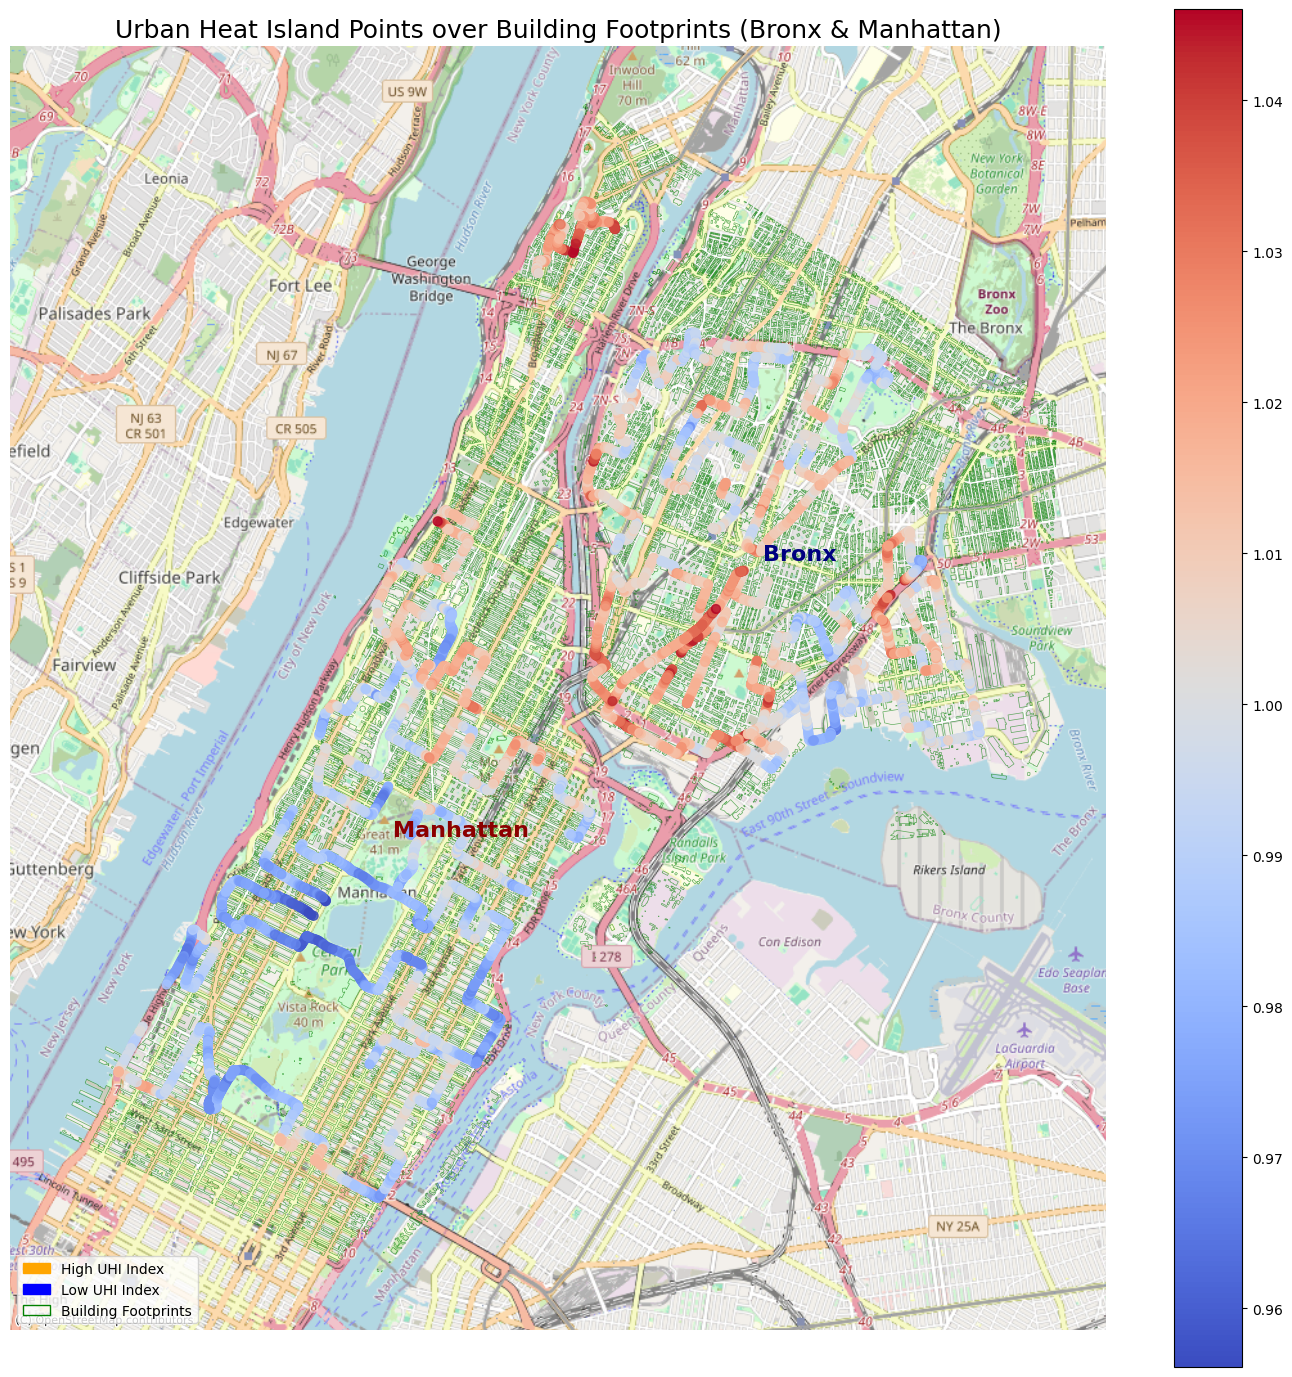

In [6]:
# Convert final_df to GeoDataFrame
uhi_gdf = gpd.GeoDataFrame(
    final_df.copy(),
    geometry=gpd.points_from_xy(final_df['Longitude'], final_df['Latitude']),
    crs='EPSG:4326'
)

# Reproject for plotting
uhi_gdf = uhi_gdf.to_crs(epsg=3857)
building_gdf = building_gdf.to_crs(epsg=3857)

# Separate UHI by location
bronx = uhi_gdf[uhi_gdf["Location"] == "Bronx"]
manhattan = uhi_gdf[uhi_gdf["Location"] == "Manhattan"]

# Plot everything
fig, ax = plt.subplots(figsize=(14, 14))

# Plot building footprints: green edges
building_gdf.plot(ax=ax, facecolor="none", edgecolor="green", linewidth=0.5, alpha=0.6)

# Plot UHI points: color shows intensity
uhi_plot = uhi_gdf.plot(
    ax=ax,
    column="UHI Index",
    cmap="coolwarm",
    markersize=40,
    legend=True,
    alpha=0.8
)

# Add basemap
ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik, alpha=0.9)

# Label Bronx and Manhattan
bronx_centroid = bronx.unary_union.centroid
manhattan_centroid = manhattan.unary_union.centroid

ax.text(bronx_centroid.x, bronx_centroid.y, "Bronx", fontsize=16, fontweight='bold', color='navy')
ax.text(manhattan_centroid.x, manhattan_centroid.y, "Manhattan", fontsize=16, fontweight='bold', color='darkred')

# Add Custom Legend
uhi_patch = mpatches.Patch(color="orange", label="High UHI Index")
cool_patch = mpatches.Patch(color="blue", label="Low UHI Index")
building_patch = mpatches.Patch(edgecolor="green", facecolor="none", label="Building Footprints")

plt.legend(handles=[uhi_patch, cool_patch, building_patch], loc="lower left", fontsize=10)

# Final formatting
ax.set_title("Urban Heat Island Points over Building Footprints (Bronx & Manhattan)", fontsize=18)
ax.set_axis_off()
plt.tight_layout()
plt.show()

# Reproject back to EPSG:4326
uhi_gdf = uhi_gdf.to_crs(epsg=4326)
building_gdf = building_gdf.to_crs(epsg=4326)

In [6]:
# Select relevant columns
building_df = building_gdf[['id', 'fid', 'layer','geometry']].copy()

# Display the first few rows
print(building_df.head())

                id   fid       layer  \
0    cugir009034.3  7624  clip_Bronx   
1    cugir009034.4  7625  clip_Bronx   
2    cugir009034.5  7626  clip_Bronx   
3    cugir009034.6  7627  clip_Bronx   
4  cugir009034.142  7829  clip_Bronx   

                                                                                                                                                 geometry  
0  POLYGON ((-73.91903 40.84820, -73.91933 40.84795, -73.91937 40.84798, -73.91945 40.84792, -73.91953 40.84797, -73.91915 40.84828, -73.91903 40.84820))  
1                                          POLYGON ((-73.92195 40.84963, -73.92191 40.84968, -73.92176 40.84961, -73.92181 40.84956, -73.92195 40.84963))  
2                                          POLYGON ((-73.92050 40.85011, -73.92045 40.85017, -73.92026 40.85007, -73.92031 40.85001, -73.92050 40.85011))  
3                                          POLYGON ((-73.92056 40.85140, -73.92053 40.85144, -73.92037 40.85138, -73.92040 40.85134, -7

In [9]:
# Clean the 'layer' column to extract borough names (e.g., "clip_Bronx" → "Bronx")
building_df["Location"] = building_df["layer"].str.replace("clip_", "", regex=False)

# Drop unused columns
building_clean_gdf = building_df[["id", "Location", "geometry"]]

# Ensure it's a GeoDataFrame
building_clean_gdf = gpd.GeoDataFrame(building_clean_gdf, geometry="geometry", crs="EPSG:4326")

# Save as GeoPackage (recommended)
building_clean_gdf.to_file("buildings.shp")

In [8]:
print("CRS: {}".format(building_clean_gdf.crs))

CRS: EPSG:4326


In [10]:
building_df["Location"].value_counts()

Location
Bronx        5926
Manhattan    3510
Name: count, dtype: int64

## Basic EDA – Understanding the Urban Landscape of Bronx and Manhattan

Before modeling Urban Heat Island (UHI) effects, I ran a foundational analysis to understand the layout and density of buildings in the Bronx and Manhattan — since the built environment plays a direct role in how heat is stored and dispersed.

### Building Count and Area

* **Bronx:** 5,926 buildings covering \~76.7 million sq ft
* **Manhattan:** 3,510 buildings covering \~126.3 million sq ft

Though the Bronx has more buildings, Manhattan’s structures are significantly larger on average — about **36,000 sq ft** compared to **13,000 sq ft** in the Bronx. This aligns with the expected difference in urban form: the Bronx has more low-rise residential structures, while Manhattan is shaped by larger commercial and high-rise buildings.

### What This Means for UHI

* The **Bronx’s heat** may stem from the **dense clustering** of smaller buildings, which limits airflow and increases surface heat retention.
* In **Manhattan**, while buildings are larger, vertical structures and parks (like Central Park) contribute to **shading and ventilation**, creating localized cooling effects.

This contrast helps explain patterns seen in earlier UHI visualizations and sets a foundation for why borough-level structural differences matter in heat modeling.


Building Count per Borough
Location
Bronx        5926
Manhattan    3510
Name: count, dtype: int64

Total Building Area (sq ft)
Location
Bronx        76723904.80
Manhattan   126304860.02
Name: area, dtype: float64

Borough Statistics


,Location,num_buildings,total_area,avg_area
0,Bronx,5926,76723904.80,12947.00
1,Manhattan,3510,126304860.02,35984.29


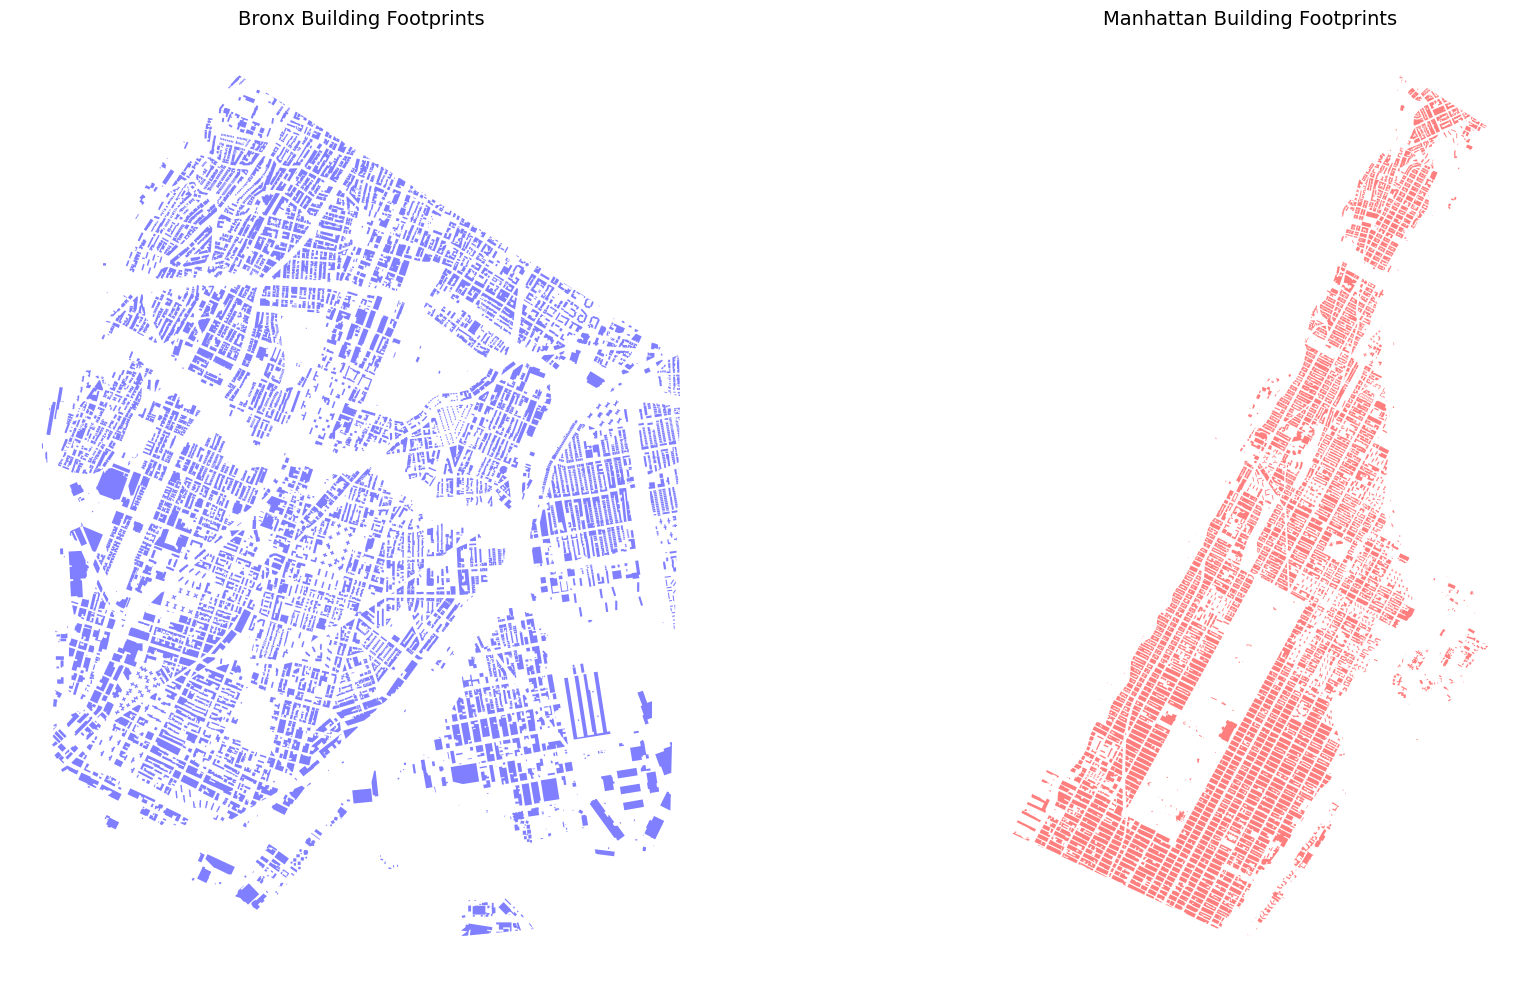

In [11]:
# Preprocess Data 
# Convert to projected CRS (EPSG:2263 for feet)
building_df = building_df.to_crs(epsg=2263)

# Calculate areas
building_df["area"] = building_df.geometry.area  # Area in square feet

# Borough Statistics 
borough_stats = building_df.groupby("Location").agg(
    num_buildings=("id", "count"),
    total_area=("area", "sum"),
    avg_area=("area", "mean")
).reset_index()

# Format numbers to avoid scientific notation
borough_stats["total_area"] = borough_stats["total_area"].round(2)
borough_stats["avg_area"] = borough_stats["avg_area"].round(2)

# Print Summary Stats 
print("\nBuilding Count per Borough")
print(building_df["Location"].value_counts())

print("\nTotal Building Area (sq ft)")
print(building_df.groupby("Location")["area"].sum().round(2))

print("\nBorough Statistics")
display(borough_stats)

# Side-by-Side Plots 
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))

# Bronx Plot
bronx = building_df[building_df["Location"] == "Bronx"]
bronx.plot(ax=ax1, alpha=0.5, color='blue')
ax1.set_title("Bronx Building Footprints", fontsize=14)
ax1.set_axis_off()

# Manhattan Plot
manhattan = building_df[building_df["Location"] == "Manhattan"]
manhattan.plot(ax=ax2, alpha=0.5, color='red')
ax2.set_title("Manhattan Building Footprints", fontsize=14)
ax2.set_axis_off()

plt.tight_layout()
plt.show()

## Deeper Dive – Advanced EDA of the Built Environment and Urban Heat Dynamics

To complement basic building stats, this analysis explores how geometry, density, and spatial design shape UHI behavior in Bronx and Manhattan. Instead of just surface area, we now look at how **form and spacing** influence thermal dynamics.

### Urban Form and Spatial Layout

| Metric                  | Bronx    | Manhattan |
| ----------------------- | -------- | --------- |
| Building Count          | 5,926    | 3,510     |
| Total Area (sq ft)      | 76.7M    | 126.3M    |
| Avg Building Area       | \~13,000 | \~36,000  |
| Median NN Distance (ft) | 123.25      |  204.88       |

* The **Bronx** has a more **compact and horizontally spread** urban layout, while **Manhattan** is denser vertically, with wider gaps between buildings.
* **Shorter distances** between Bronx buildings can lead to **less airflow** and **more trapped heat**, forming a more continuous heat layer.
* **Manhattan’s spacing**, while looser, combines with complex structures that create **localized hotspots** and **thermal contrasts**.

### Building Shape and Ventilation Potential

| Metric             | Bronx | Manhattan |
| ------------------ | ----- | --------- |
| Mean Compactness   | 0.57  | 0.49      |
| % Highly Irregular | 2.45%    | 6.70%        |

* The Bronx’s more **regular shapes** support smoother airflow, while Manhattan’s irregular forms may **disrupt ventilation**, increasing microclimate variability.
* These differences are important: **irregular, complex buildings** can block wind and **retain heat longer**, especially in tightly packed areas.

### Large Structures and Thermal Imbalance

Outliers matter: nearly **800 buildings exceed 3× the 75th percentile in size**, including highly irregular structures.

* One Bronx building spans over **768,000 sq ft** with extremely low compactness — behaving as a **thermal anchor** that stores and slowly releases heat.

These buildings don’t just affect themselves — they alter conditions in surrounding blocks, intensifying UHI effects in nearby residential areas.

### Urban Inequality and Heat Exposure

* **Manhattan shows higher inequality** in building size, leading to abrupt transitions from small buildings to skyscrapers. These shifts can cause **uneven heat distribution**, creating “cool gaps” by day that become **radiant zones** at night.
* In contrast, the **Bronx’s more uniform structure** leads to a **flatter but more consistent UHI surface** — fewer extremes, but less relief.

### Summary: Contrasting Heat Behaviors

| Factor           | Bronx                          | Manhattan                              |
| ---------------- | ------------------------------ | -------------------------------------- |
| Urban Form       | Compact, low-rise              | Tall, irregular, mixed-density         |
| Heat Behavior    | Continuous surface heat        | Patchy, localized hotspots             |
| Primary Risk     | Persistent heat accumulation   | Thermal imbalance + night radiation    |
| Mitigation Focus | Broad cooling (trees, roofing) | Targeted solutions (ventilation paths) |

In [12]:
# 1. Calculate Building Compactness
# Compactness is a shape metric: 1 for a perfect circle, lower for irregular shapes.
# Formula: 4 * pi * Area / Perimeter^2
# We use 3.14159 for pi for consistency with common approximations in such calculations.
building_df['compactness'] = 4 * 3.14159 * building_df['area'] / (building_df.geometry.length**2)

# 2. Calculate Average Nearest Neighbor Distance 
# Measures building density by finding the average distance to the 5 closest building centroids.
coords = np.column_stack([building_df.geometry.centroid.x, building_df.geometry.centroid.y])
nbrs = NearestNeighbors(n_neighbors=5, algorithm='kd_tree').fit(coords)
distances, _ = nbrs.kneighbors(coords)
building_df['avg_neighbor_dist_ft'] = distances.mean(axis=1)

# --- Insights and Feature Aggregation ---
print("Advanced EDA: Built Environment and Urban Heat Dynamics\n")

# Calculate metrics for "Urban Form and Spatial Layout" and "Building Shape and Ventilation Potential" tables.
# This combines calculations needed for multiple rows and sections of your write-up.
borough_features = building_df.groupby('Location').agg(
    # Building Count (for table)
    building_count=('Location', 'size'),
    # Total Area (sq ft) (for table)
    total_area_sqft=('area', 'sum'),
    # Average Building Area (for table)
    avg_building_area=('area', 'mean'),
    # Median Nearest Neighbor Distance (for table)
    median_nn_distance_ft=('avg_neighbor_dist_ft', 'median'),
    # Mean Compactness (for table)
    mean_compactness=('compactness', 'mean'),
    # Percentage of Highly Irregular Buildings (for table)
    # Defined as compactness < 0.2, as per your Block 3 original logic.
    pct_highly_irregular=('compactness', lambda x: (x < 0.2).mean() * 100) # Express as percentage
)

print("Urban Form and Spatial Layout & Building Shape and Ventilation Potential Metrics")
# Format for readability, matching your table's approximate values.
# Note: 'total_area_sqft' will be large, might need manual formatting for 'M' in markdown table.
print(borough_features.round(2).to_string())
print("\n" + "="*80 + "\n") # Separator for clarity


# Analyze Outliers: Large Structures and Thermal Imbalance
q75_area = building_df['area'].quantile(0.75)
# Filter buildings exceeding 3x the 75th percentile area.
outliers_large = building_df[building_df['area'] > q75_area * 3]
print(f"Large Structures and Thermal Imbalance Outliers")
print(f"Nearly {len(outliers_large):,} buildings exceed 3x the 75th percentile in size ({q75_area * 3:,.0f} sq ft).\n")

# Find the largest Bronx building with low compactness
# Assuming "extremely low compactness" implies looking for a compactness value below a certain threshold, e.g., 0.2
bronx_thermal_anchor = outliers_large[
    (outliers_large['Location'] == 'Bronx') &
    (outliers_large['compactness'] < 0.2) # Use the "highly irregular" threshold for "extremely low"
].sort_values('area', ascending=False).head(1)

if not bronx_thermal_anchor.empty:
    print(f"Specific thermal anchor example (Bronx, largest irregular outlier):")
    print(f"- Area: {bronx_thermal_anchor['area'].iloc[0]:,.0f} sq ft")
    print(f"- Compactness: {bronx_thermal_anchor['compactness'].iloc[0]:.3f}\n")
else:
    print("Could not find a specific large Bronx building with extremely low compactness among outliers based on criteria.\n")

print("Largest buildings among these outliers (top 5 by area):")
print(outliers_large[['Location', 'area', 'compactness']].sort_values('area', ascending=False).head(5).to_string())

Advanced EDA: Built Environment and Urban Heat Dynamics

Urban Form and Spatial Layout & Building Shape and Ventilation Potential Metrics
           building_count  total_area_sqft  avg_building_area  median_nn_distance_ft  mean_compactness  pct_highly_irregular
Location                                                                                                                    
Bronx                5926      76723904.80           12947.00                 123.25              0.57                  2.45
Manhattan            3510     126304860.02           35984.29                 204.88              0.49                  6.70


Large Structures and Thermal Imbalance Outliers
Nearly 793 buildings exceed 3x the 75th percentile in size (70,381 sq ft).

Specific thermal anchor example (Bronx, largest irregular outlier):
- Area: 768,459 sq ft
- Compactness: 0.039

Largest buildings among these outliers (top 5 by area):
       Location      area  compactness
5777      Bronx 768459.44    

In [13]:
print("\nBuilding Data Shape:")
print(building_df.shape)

print("\nBuilding Data CRS:")
print("CRS: {}".format(building_df.crs))

print("\nBuilding Data Unique Entries:")
print(building_df.nunique())


Building Data Shape:
(9436, 6)

Building Data CRS:
CRS: EPSG:2263

Building Data Unique Entries:
id                      9436
Location                   2
geometry                9433
area                    9433
compactness             9433
avg_neighbor_dist_ft    9433
dtype: int64


## Engineering Spatial Features from Building Footprints

To better predict Urban Heat Island (UHI) intensity, I transformed the NYC building footprint dataset into spatial features that reflect the urban form around each UHI point. Since there wasn’t a one-to-one mapping between UHI coordinates and individual buildings, I adopted a spatial summarization approach.

### Why This Was Needed
* **Mismatch in data sizes**:
  The building dataset (9,436 entries) didn’t match the combined train/test UHI entries (11,229).
* **No direct join**:
  UHI points only had latitude and longitude, and I couldn't use these directly as features.
* **Goal**:
  Capture *contextual building characteristics* around each UHI point without violating the constraints.

### The Strategy
1. **Buffer Zones**:
   Around each UHI coordinate, I created circular zones with radii of:

   * 50m
   * 100m
   * 150m
   * 200m

2. **Within Each Buffer**, I computed:
   * Count of buildings
   * Summary stats (mean, median, std, sum) for:

     * `area`
     * `compactness`
     * `avg_neighbor_dist_ft`
   * **Built-up ratio**:
     Total building area ÷ buffer area (a proxy for urban density)

3. **Why Buffers Work**:
   * UHI is influenced by the *surrounding built form*, not individual structures.
   * Buffers allow us to approximate urban context without using GPS directly.

### Result
* These aggregated spatial features enriched the dataset with localized urban morphology.
* The model now has access to *urban density, compactness, and spacing patterns* across multiple scales—improving its ability to learn how the environment influences heat distribution.

In [14]:
train_coords.head(3)

,Longitude,Latitude
0,-73.96,40.80
1,-73.97,40.79
2,-73.88,40.81


In [15]:
def create_spatial_features(uhi_coords_df, buildings_gdf, buffer_sizes=[50, 100, 150, 200]):
    """
    Engineered spatial features from building footprints within buffers around UHI points.
    
    Args:
        uhi_coords_df: DataFrame with 'latitude' and 'longitude' columns
        buildings_gdf: GeoDataFrame of building footprints with metrics
        buffer_sizes: List of buffer radii in meters
        
    Returns:
        DataFrame with engineered features (no geometry/coordinates)
    """
    # Convert to GeoDataFrame in Web Mercator (meters)
    gdf = gpd.GeoDataFrame(
        uhi_coords_df,
        geometry=gpd.points_from_xy(uhi_coords_df.Longitude, uhi_coords_df.Latitude),
        crs="EPSG:4326"
    ).to_crs("EPSG:3857")  # Convert to meter-based CRS
    
    # Buffer buildings to avoid repeated spatial joins
    buildings_buffered = buildings_gdf.to_crs("EPSG:3857").copy()
    
    results = []
    for radius in buffer_sizes:
        # Create buffers
        buffered = gdf.copy()
        buffered['geometry'] = buffered.geometry.buffer(radius)
        buffered['buffer_area'] = np.pi * (radius ** 2)  # Area of circular buffer
        
        # Spatial join with buildings
        joined = gpd.sjoin(buffered, buildings_buffered, how='left', predicate='intersects')
        
        # Aggregate features
        agg_features = joined.groupby(level=0).agg({
            'area': ['count', 'mean', 'median', 'std', 'sum'],
            'compactness': ['mean', 'median', 'std'],
            'avg_neighbor_dist_ft': ['mean', 'median', 'std'],
        })
        
        # Flatten multi-index columns
        agg_features.columns = [f"{radius}m_{stat}_{var}" 
                              for var, stat in agg_features.columns]
        
        # Align buffer areas with aggregated features
        buffer_areas = buffered['buffer_area'].loc[agg_features.index]
        agg_features[f"{radius}m_builtup_ratio"] = (
            agg_features[f"{radius}m_sum_area"] / buffer_areas
        )
        
        results.append(agg_features)
    
    # Combine all buffer sizes
    return pd.concat(results, axis=1).fillna(0)

# Usage:
if __name__ == "__main__":
    # 1. Generate spatial features
    train_spatial = create_spatial_features(train_coords, building_df)
    test_spatial = create_spatial_features(test_coords, building_df)
    
    # 2. Merge with existing data (excluding coordinates)
    train_enhanced = pd.concat([selected_features_df, train_spatial], axis=1)
    test_enhanced = pd.concat([final_test1, test_spatial], axis=1)

    # Move 'UHI Index' to last column (for both train and test)
    for i, df in enumerate([train_enhanced, test_enhanced]):
        if "UHI Index" in df.columns:
            # Store UHI values
            uhi_values = df["UHI Index"].copy()
            # Drop the column
            df.drop(columns=["UHI Index"], inplace=True)
            # Re-add as last column
            df["UHI Index"] = uhi_values        

# Verify
print("Last 5 train columns:", train_enhanced.columns.tolist()[-5:])
print("Last 5 test columns:", test_enhanced.columns.tolist()[-5:])

Last 5 train columns: ['200m_mean_avg_neighbor_dist_ft', '200m_median_avg_neighbor_dist_ft', '200m_std_avg_neighbor_dist_ft', '200m_builtup_ratio', 'UHI Index']
Last 5 test columns: ['200m_mean_avg_neighbor_dist_ft', '200m_median_avg_neighbor_dist_ft', '200m_std_avg_neighbor_dist_ft', '200m_builtup_ratio', 'UHI Index']


In [16]:
def check_missingness(df, label="Dataset"):
    missing_percent = (df.isnull().sum() / len(df)) * 100
    print(f"\nMissing values (%): {label}")
    return missing_percent[missing_percent > 0].sort_values(ascending=False)

check_missingness(train_enhanced, "Enhanced Train") 
check_missingness(test_enhanced, "Enhanced Test")


Missing values (%): Enhanced Train

Missing values (%): Enhanced Test


Series([], dtype: float64)

In [17]:
# Quick look at first rows
print("Train Dataset")
display(train_enhanced.head(3))  # Reduced to 3 rows for brevity

print("Test Dataset")
display(test_enhanced.head(3))  # Reduced to 3 rows for brevity

# Shape (row x column count)
print("Train Dataset Shape:", train_enhanced.shape)
print("Test Dataset Shape:", test_enhanced.shape)

def show_uniqueness_extremes(df, name="Dataset"):
    nunique = df.nunique()
    print(f"\n{name} - Top 5 columns with highest uniqueness:")
    display(nunique.sort_values(ascending=False).head(5))
    print(f"\n{name} - Top 5 columns with lowest uniqueness:")
    display(nunique.sort_values().head(5))

show_uniqueness_extremes(train_enhanced, "Train Enhanced")
show_uniqueness_extremes(test_enhanced, "Test Enhanced")

Train Dataset


,datetime,Location,Wind Direction degrees,solar_accumulation_6am,Temp_1hr_MA,Wind V,Avg Wind Speed m/s,Temp_Change_30min,Temp_3hr_MA,mins_from_3pm,Solar Flux W/m^2,Air Temp at Surface degC,50m_count_area,50m_mean_area,50m_median_area,50m_std_area,50m_sum_area,50m_mean_compactness,50m_median_compactness,50m_std_compactness,50m_mean_avg_neighbor_dist_ft,50m_median_avg_neighbor_dist_ft,50m_std_avg_neighbor_dist_ft,50m_builtup_ratio,100m_count_area,100m_mean_area,100m_median_area,100m_std_area,100m_sum_area,100m_mean_compactness,100m_median_compactness,100m_std_compactness,100m_mean_avg_neighbor_dist_ft,100m_median_avg_neighbor_dist_ft,100m_std_avg_neighbor_dist_ft,100m_builtup_ratio,150m_count_area,150m_mean_area,150m_median_area,150m_std_area,150m_sum_area,150m_mean_compactness,150m_median_compactness,150m_std_compactness,150m_mean_avg_neighbor_dist_ft,150m_median_avg_neighbor_dist_ft,150m_std_avg_neighbor_dist_ft,150m_builtup_ratio,200m_count_area,200m_mean_area,200m_median_area,200m_std_area,200m_sum_area,200m_mean_compactness,200m_median_compactness,200m_std_compactness,200m_mean_avg_neighbor_dist_ft,200m_median_avg_neighbor_dist_ft,200m_std_avg_neighbor_dist_ft,200m_builtup_ratio,UHI Index
0,2021-07-24 15:51:00,Manhattan,0.76,-0.73,0.07,0.91,0.63,-1.25,1.08,0.98,-1.52,-1.14,1,12285.39,12285.39,0.00,12285.39,0.50,0.50,0.00,903.83,903.83,0.00,1.56,1,12285.39,12285.39,0.00,12285.39,0.50,0.50,0.00,903.83,903.83,0.00,0.39,1,12285.39,12285.39,0.00,12285.39,0.50,0.50,0.00,903.83,903.83,0.00,0.17,1,12285.39,12285.39,0.00,12285.39,0.50,0.50,0.00,903.83,903.83,0.00,0.10,0.98
1,2021-07-24 15:13:00,Manhattan,-0.18,-1.00,-1.60,0.24,0.02,-1.12,0.72,-1.24,0.73,-1.14,3,48446.85,65203.53,29654.90,145340.56,0.41,0.32,0.23,223.85,229.32,20.04,18.51,7,49294.49,25455.67,41512.34,345061.45,0.41,0.39,0.19,227.46,229.32,24.30,10.98,8,45203.03,23913.94,40137.42,361624.24,0.43,0.42,0.19,230.46,232.69,24.04,5.12,11,57740.14,25455.67,48882.05,635141.49,0.41,0.44,0.17,231.88,236.07,20.92,5.05,0.99
2,2021-07-24 15:47:00,Bronx,-0.43,0.26,1.29,0.35,0.63,-0.05,-0.82,0.66,1.08,0.33,5,27520.30,24582.44,15850.36,137601.49,0.37,0.35,0.16,187.38,168.90,39.40,17.52,6,23127.95,23220.07,17797.28,138767.73,0.41,0.43,0.17,181.13,164.40,38.42,4.42,9,24415.78,21857.69,23944.33,219742.02,0.50,0.53,0.20,184.94,168.90,35.27,3.11,16,26259.12,18276.26,29676.97,420145.98,0.51,0.52,0.19,180.41,168.74,36.28,3.34,1.00


Test Dataset


,datetime,Location,solar_accumulation_6am,Wind V,Temp_Change_30min,Temp_3hr_MA,Wind Direction degrees,Solar Flux W/m^2,Avg Wind Speed m/s,mins_from_3pm,Temp_1hr_MA,Air Temp at Surface degC,50m_count_area,50m_mean_area,50m_median_area,50m_std_area,50m_sum_area,50m_mean_compactness,50m_median_compactness,50m_std_compactness,50m_mean_avg_neighbor_dist_ft,50m_median_avg_neighbor_dist_ft,50m_std_avg_neighbor_dist_ft,50m_builtup_ratio,100m_count_area,100m_mean_area,100m_median_area,100m_std_area,100m_sum_area,100m_mean_compactness,100m_median_compactness,100m_std_compactness,100m_mean_avg_neighbor_dist_ft,100m_median_avg_neighbor_dist_ft,100m_std_avg_neighbor_dist_ft,100m_builtup_ratio,150m_count_area,150m_mean_area,150m_median_area,150m_std_area,150m_sum_area,150m_mean_compactness,150m_median_compactness,150m_std_compactness,150m_mean_avg_neighbor_dist_ft,150m_median_avg_neighbor_dist_ft,150m_std_avg_neighbor_dist_ft,150m_builtup_ratio,200m_count_area,200m_mean_area,200m_median_area,200m_std_area,200m_sum_area,200m_mean_compactness,200m_median_compactness,200m_std_compactness,200m_mean_avg_neighbor_dist_ft,200m_median_avg_neighbor_dist_ft,200m_std_avg_neighbor_dist_ft,200m_builtup_ratio,UHI Index
0,2021-07-24 15:35:00,Bronx,0.89,0.44,-0.98,-0.95,-0.33,-0.90,0.63,0.03,0.86,-0.51,2,2043.36,2043.36,965.46,4086.72,0.66,0.66,0.12,75.87,75.87,13.08,0.52,8,9508.36,6550.55,10063.99,76066.89,0.55,0.56,0.19,108.74,97.72,42.83,2.42,14,9280.47,6569.51,8732.45,129926.63,0.56,0.58,0.18,116.45,113.04,35.98,1.84,22,11300.83,9773.82,12441.06,248618.22,0.55,0.58,0.18,121.99,125.09,34.07,1.98,1.00
1,2021-07-24 15:53:00,Manhattan,-1.19,0.70,-1.65,1.12,1.14,0.85,0.47,1.30,0.27,-0.72,3,39767.45,24986.28,27802.93,119302.34,0.66,0.66,0.05,227.03,221.36,9.94,15.19,5,48939.88,60212.80,23395.32,244699.39,0.55,0.61,0.17,224.12,221.36,10.98,7.79,7,44529.19,46441.87,21850.51,311704.36,0.46,0.49,0.22,213.46,221.36,31.90,4.41,15,34936.28,24986.28,27448.59,524044.23,0.45,0.49,0.21,178.87,177.10,43.47,4.17,1.01
2,2021-07-24 15:18:00,Bronx,1.35,-1.70,1.16,-1.20,-1.71,-1.25,-0.44,-0.92,0.02,1.60,1,57310.57,57310.57,0.00,57310.57,0.54,0.54,0.00,216.28,216.28,0.00,7.30,3,22881.99,10785.22,30252.02,68645.98,0.54,0.54,0.20,259.19,255.51,44.87,2.19,7,22367.46,10785.22,26798.71,156572.21,0.50,0.54,0.19,202.31,175.78,60.58,2.22,12,24066.81,11153.73,28906.77,288801.71,0.53,0.57,0.18,182.88,169.37,52.25,2.30,1.01


Train Dataset Shape: (8983, 61)
Test Dataset Shape: (2246, 61)

Train Enhanced - Top 5 columns with highest uniqueness:


...

Location                     2
50m_count_area              10
mins_from_3pm               13
Air Temp at Surface degC    14
Avg Wind Speed m/s          18
dtype: int64


Test Enhanced - Top 5 columns with highest uniqueness:


200m_sum_area                     1729
200m_builtup_ratio                1729
200m_mean_area                    1729
200m_mean_avg_neighbor_dist_ft    1729
200m_mean_compactness             1729
dtype: int64


Test Enhanced - Top 5 columns with lowest uniqueness:


Location                     2
50m_count_area              10
mins_from_3pm               13
Air Temp at Surface degC    14
Avg Wind Speed m/s          18
dtype: int64

## Buffer Visualization: Purpose and Reasoning

This visualization illustrates how buffer radius affects the spatial context captured around UHI measurement points. The goal is to understand how different buffer sizes influence the building features aggregated for modeling Urban Heat Island intensity.

The buffers are generated around each UHI location. Within each buffer, building-level attributes—such as total footprint area, number of structures, and shape descriptors—are computed. These spatial features are then used as input to the regression model predicting UHI index.

### Why This Matters

The choice of buffer size is critical. It defines the spatial boundary within which environmental features are considered relevant. A buffer that is too small may miss surrounding context, while one that is too large may dilute local effects with unrelated data.

This visualization allows for:
* A direct comparison of spatial coverage across buffer sizes.
* Visual verification that buffers are correctly aligned with UHI locations.
* An intuitive understanding of how much building data is included at each radius.

### Technical Notes
* Buffers are created around UHI points, not buildings.
* The radius can be adjusted dynamically from 50m to 200m.
* A subset of points and buildings is sampled to ensure performance and clarity.
* Buffers are styled to visually reflect scale differences across settings.

### Use Case in Modeling
By observing how features vary with buffer size, I can empirically test which radius results in the most informative spatial features—measured by R² on validation data. This visualization directly supports that decision process and helps justify buffer choices in the final modeling pipeline.

In [18]:
def create_interactive_buffer_map(uhi_points, buildings, min_buffer=50, max_buffer=200):
    """
    Creates an interactive buffer map:
    - Interactive slider when running in Kaggle edit mode.
    - Static interactive map (HTML file) when saving a Kaggle Version.
    """

    # Convert to WGS84 if not already
    if uhi_points.crs != "EPSG:4326":
        uhi_points = uhi_points.to_crs("EPSG:4326")
    if buildings.crs != "EPSG:4326":
        buildings = buildings.to_crs("EPSG:4326")

    # Create base map
    if uhi_points.empty:
        print("UHI points GeoDataFrame is empty. Cannot create map center.")
        return None
    center = [uhi_points.geometry.iloc[0].y, uhi_points.geometry.iloc[0].x]
    m = folium.Map(location=center, zoom_start=15, tiles='CartoDB positron')

    # Sample buildings for performance
    if not buildings.empty:
        buildings_sample = buildings.sample(min(1000, len(buildings))) if len(buildings) > 1000 else buildings
        folium.GeoJson(
            buildings_sample,
            name='Buildings',
            style_function=lambda x: {'color': 'orange', 'weight': 0.5, 'fillOpacity': 0.3}
        ).add_to(m)

    # Color scale for buffers
    colormap = cm.LinearColormap(['blue', 'yellow', 'red'],
                                 vmin=min_buffer, vmax=max_buffer,
                                 caption='Buffer Radius (m)')
    colormap.add_to(m)

    # Container for buffer circles
    buffer_container = folium.FeatureGroup(name="Buffers")
    m.add_child(buffer_container)

    def update_buffers(buffer_size=100):
        """Dynamically update buffers"""
        buffer_container._children = OrderedDict()  # clear old buffers

        if not uhi_points.empty:
            sample_points = uhi_points.sample(min(50, len(uhi_points)))
            for _, row in sample_points.iterrows():
                folium.Circle(
                    location=[row.geometry.y, row.geometry.x],
                    radius=buffer_size,
                    color=colormap(buffer_size),
                    fill=True,
                    fill_opacity=0.2,
                    popup=f"Buffer: {buffer_size}m",
                ).add_to(buffer_container)

        print(f"Current buffer size: {buffer_size}m")
        return m

    folium.LayerControl().add_to(m)

    # Switch behavior depending on Kaggle run mode
    if os.environ.get("KAGGLE_KERNEL_RUN_TYPE") == "Interactive":
        # Notebook editing mode → live slider widget
        slider = IntSlider(
            value=100,
            min=min_buffer,
            max=max_buffer,
            step=10,
            description='Buffer Size:',
            continuous_update=True
        )
        interact(update_buffers, buffer_size=slider)
        return m
    else:
        # Save Version mode → export HTML (avoid hanging)
        output_path = "/kaggle/working/buffer_explorer.html"
        update_buffers(100)  # default buffer size
        m.save(output_path)
        print(f"Saved static interactive map to {output_path}")
        return None

In [ ]:
# Usage
if __name__ == "__main__":
    # Example: convert train_coords into GeoDataFrame
    uhi_points = gpd.GeoDataFrame(
        train_coords,
        geometry=gpd.points_from_xy(train_coords.Longitude, train_coords.Latitude),
        crs="EPSG:4326"
    )

    # Create map
    buffer_map = create_interactive_buffer_map(uhi_points, building_df)

    # Only display in interactive mode
    if buffer_map:
        display(buffer_map)

## Urban Buffer Feature Summary

After engineering spatial features using building footprint data within buffers of 50m to 200m around each UHI observation point, we generated a set of descriptive metrics to characterize the built environment at various scales. These features aim to capture urban morphology, density, and spatial arrangement, all of which can influence UHI intensity.

### 1. **Feature Groups**
Each buffer radius (50m, 100m, 150m, 200m) includes the following types of metrics:

* `count_area`: Number of buildings within the buffer.
* `mean_area`, `median_area`, `std_area`, `sum_area`: Distribution of building sizes (in square meters).
* `mean_compactness`, `median_compactness`, `std_compactness`: Shape complexity of buildings; values closer to 1 indicate more compact shapes.
* `mean_avg_neighbor_dist_ft`, etc.: Average distance between buildings, capturing spatial dispersion.
* `builtup_ratio`: Ratio of built area to total buffer area — a proxy for local urban density.

### 2. **General Observations**

* **Scale progression:** As buffer radius increases, both the number of buildings and cumulative building area (`sum_area`) increase. This shows spatial coverage expanding as expected.
  
* **Compactness:**
  * Mean compactness values range from \~0.38 (50m) to \~0.48 (200m), suggesting moderate shape regularity.
  * Standard deviation of compactness remains low (\~0.1–0.17), indicating limited variability in shape complexity across buildings.

* **Neighbor distances:**
  * Mean distance between neighboring buildings increases slightly with buffer size (from \~194ft to \~217ft), suggesting more spread out buildings in wider buffers.
  * The large maximum of \~900ft likely corresponds to outliers or isolated buildings.

* **Built-up Ratio:**
  * Decreases with increasing buffer size (from \~13% at 50m to \~3.5% at 200m), indicating that urban density thins out at broader scales.

### 3. **Distribution Insights**

* **Highly skewed distributions** are observed in many features:
  * Maximum values (e.g., `sum_area`, `std_area`) are disproportionately high, indicating the presence of dense urban pockets or outlier zones.
  * Several features have **0 values at the 25th percentile**, especially at smaller buffers. This means a significant number of UHI points fall in low or non-built-up areas at close range — a valuable insight for urban heat prediction.

### 4. **Modeling Implications**

* **Feature selection** or **transformation** (e.g., log-scaling or binning) may help normalize highly skewed distributions.
* **Built-up ratio** and **neighbor distance metrics** show meaningful variation across scales, which could be important for learning scale-dependent UHI patterns.
* The consistency in compactness and area-related stats across scales suggests strong underlying spatial patterns, which can be leveraged by tree-based models like Random Forest or Gradient Boosting.

### 5. **Next Steps**

* Consider **correlation analysis** across buffer levels to detect redundant features.
* Use model-based feature importance to identify which buffer scale captures the most predictive spatial context.
* Explore whether **multi-scale feature aggregation** (e.g., min/max across scales) offers more generalizable insights than individual buffer sizes alone.

In [19]:
# Get the column slice from index 12 to 60 (Python indexing is exclusive on the stop index)
engineered_cols = train_enhanced.columns[12:60]

# Describe only the engineered buffer features
train_enhanced[engineered_cols].describe()

,50m_count_area,50m_mean_area,50m_median_area,50m_std_area,50m_sum_area,50m_mean_compactness,50m_median_compactness,50m_std_compactness,50m_mean_avg_neighbor_dist_ft,50m_median_avg_neighbor_dist_ft,50m_std_avg_neighbor_dist_ft,50m_builtup_ratio,100m_count_area,100m_mean_area,100m_median_area,100m_std_area,100m_sum_area,100m_mean_compactness,100m_median_compactness,100m_std_compactness,100m_mean_avg_neighbor_dist_ft,100m_median_avg_neighbor_dist_ft,100m_std_avg_neighbor_dist_ft,100m_builtup_ratio,150m_count_area,150m_mean_area,150m_median_area,150m_std_area,150m_sum_area,150m_mean_compactness,150m_median_compactness,150m_std_compactness,150m_mean_avg_neighbor_dist_ft,150m_median_avg_neighbor_dist_ft,150m_std_avg_neighbor_dist_ft,150m_builtup_ratio,200m_count_area,200m_mean_area,200m_median_area,200m_std_area,200m_sum_area,200m_mean_compactness,200m_median_compactness,200m_std_compactness,200m_mean_avg_neighbor_dist_ft,200m_median_avg_neighbor_dist_ft,200m_std_avg_neighbor_dist_ft,200m_builtup_ratio
count,8983.00,8983.00,8983.00,8983.00,8983.00,8983.00,8983.00,8983.00,8983.00,8983.00,8983.00,8983.00,8983.00,8983.00,8983.00,8983.00,8983.00,8983.00,8983.00,8983.00,8983.00,8983.00,8983.00,8983.00,8983.00,8983.00,8983.00,8983.00,8983.00,8983.00,8983.00,8983.00,8983.00,8983.00,8983.00,8983.00,8983.00,8983.00,8983.00,8983.00,8983.00,8983.00,8983.00,8983.00,8983.00,8983.00,8983.00,8983.00
mean,2.24,44813.35,43154.48,16966.01,104607.40,0.38,0.38,0.10,194.43,193.36,19.91,13.32,5.11,43195.87,38390.20,25441.02,189816.40,0.43,0.43,0.14,210.51,207.80,30.33,6.04,9.48,40476.09,34275.78,29965.00,321003.07,0.46,0.46,0.16,215.05,211.95,38.18,4.54,14.67,38337.31,31476.80,31238.03,448152.95,0.48,0.49,0.17,217.96,213.99,43.30,3.57
std,1.46,45352.81,46129.20,24118.42,100123.71,0.20,0.21,0.10,108.05,108.81,21.42,12.75,3.33,41603.65,41587.23,33481.43,144659.97,0.17,0.18,0.08,113.53,114.95,21.94,4.60,6.04,33691.68,35964.95,30620.12,208025.13,0.14,0.16,0.06,113.32,114.96,23.40,2.94,9.23,30065.95,33682.66,27698.32,249325.94,0.11,0.14,0.05,114.18,115.73,24.89,1.98
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,1.00,12293.61,8912.71,0.00,30235.05,0.26,0.25,0.00,145.87,142.61,0.00,3.85,3.00,15518.19,9375.65,7864.70,93465.19,0.36,0.33,0.10,157.74,152.74,16.59,2.98,6.00,16281.58,9470.05,13690.97,190732.87,0.40,0.37,0.14,160.75,155.28,25.61,2.70,9.00,16389.05,9012.38,16217.71,299324.12,0.43,0.40,0.15,162.28,157.35,30.12,2.38
50%,2.00,31824.20,28398.10,8637.83,80307.34,0.41,0.40,0.09,204.30,202.65,15.06,10.23,5.00,31277.57,23032.96,18721.46,163377.15,0.45,0.44,0.16,208.09,204.54,28.54,5.20,9.00,31315.83,20502.66,24144.73,287918.29,0.47,0.47,0.17,205.57,202.65,35.56,4.07,13.00,29737.65,18242.93,26029.85,416817.35,0.49,0.49,0.18,202.67,200.31,40.25,3.32
75%,3.00,67883.75,68141.12,24901.80,151090.34,0.53,0.54,0.18,255.79,256.22,31.91,19.24,7.00,60412.42,55531.72,33799.73,255818.42,0.54,0.57,0.20,259.68,258.93,41.32,8.14,12.00,54308.95,45279.81,38827.98,432153.77,0.54,0.58,0.20,252.18,253.88,47.85,6.11,18.00,51051.31,38816.74,39418.79,597915.78,0.55,0.58,0.20,249.10,248.58,52.30,4.76
max,9.00,523759.61,523759.61,369974.82,680067.14,0.80,0.80,0.48,903.83,903.83,149.45,86.59,23.00,523759.61,523759.61,440080.30,917251.48,0.79,0.79,0.43,903.83,903.83,169.13,29.20,38.00,505844.95,505844.95,370068.07,1131004.79,0.79,0.79,0.45,903.83,903.83,311.99,16.00,55.00,254580.94,254580.94,355340.98,1290610.81,0.78,0.78,0.42,903.83,903.83,265.81,10.27


## Urban Structure Features and Their Relationship with UHI

This analysis looks at how urban structural characteristics—like building area, compactness, and spacing—measured across different buffer zones (50m to 200m) relate to the Urban Heat Island (UHI) Index. The goal is to understand how features of the built environment might influence local heat intensity.

### Key Takeaways

#### 1. Consistency Within Buffers

* **Area Metrics** (mean, median, sum) are tightly correlated within each buffer. For example, in the 50m zone, `mean_area` and `median_area` are almost identical (corr ≈ 0.98). These features all reflect the size of buildings nearby.
* **Built-up Ratio** is nearly perfectly correlated with `sum_area` (≈ 1.00) in each buffer, as both essentially capture total built footprint.
* **Compactness & Neighbor Distance** metrics show high internal agreement too—mean and median values for each are tightly aligned across zones.

#### 2. Consistency Across Buffers

* Structural features are also correlated *across* buffer sizes. E.g., `50m_mean_area` has strong positive relationships with `100m_mean_area`, `150m_mean_area`, etc.
* This tells us that areas with dense or compact buildings in a small zone (50m) tend to remain so in broader areas (100m–200m).

#### 3. Relationship with UHI Index

* **Low to Moderate Correlation:** The UHI Index shows only weak to modest relationships with individual structural features. For example:

  * `200m_median_area`: 0.28
  * `150m_builtup_ratio`: 0.26
* **Larger Buffers Matter Slightly More:** Metrics from larger buffers (150m–200m) show slightly stronger correlation with UHI than immediate surroundings (50m–100m), suggesting broader urban context may better explain heat patterns.
* **No Single Driver:** No one feature clearly dominates; UHI seems influenced by a *combination* of spatial and environmental factors.

### Technical Considerations

* **Multicollinearity Alert:** Features like `mean_area`, `sum_area`, and `builtup_ratio` carry redundant information. For modeling, it’s worth reducing this overlap using techniques like PCA or regularized regression.
* **Correlation ≠ Causation:** These are *absolute* correlation values. They show strength, not direction. Also, they capture only linear relationships; more complex, non-linear effects could be at play.
* **Exploratory, Not Predictive:** These stats help us understand patterns, but don’t yet explain or predict UHI directly.

### Final Thoughts

Urban form clearly has a structured internal logic—buildings that are large tend to be close together, and built-up areas cluster across space. However, their impact on UHI appears subtle and spread out. This calls for deeper modeling that blends structural, material, and environmental data to fully capture what drives urban heat.

In [20]:
# Ensure engineered_cols is a list
if not isinstance(engineered_cols, list):
    engineered_cols = list(engineered_cols)

# Add target safely
temp_cols = engineered_cols.copy()
temp_cols.append('UHI Index')

# Compute absolute correlation matrix including the target
encorr_matrix = train_enhanced[temp_cols].corr().abs()

# Display full correlation matrix
display(encorr_matrix)

# Show correlations of engineered features with the target only
target_corr = encorr_matrix['UHI Index'].drop('UHI Index').sort_values(ascending=False)
print("\nCorrelation of engineered features with UHI Index:")
display(target_corr)


,50m_count_area,50m_mean_area,50m_median_area,50m_std_area,50m_sum_area,50m_mean_compactness,50m_median_compactness,50m_std_compactness,50m_mean_avg_neighbor_dist_ft,50m_median_avg_neighbor_dist_ft,50m_std_avg_neighbor_dist_ft,50m_builtup_ratio,100m_count_area,100m_mean_area,100m_median_area,100m_std_area,100m_sum_area,100m_mean_compactness,100m_median_compactness,100m_std_compactness,100m_mean_avg_neighbor_dist_ft,100m_median_avg_neighbor_dist_ft,100m_std_avg_neighbor_dist_ft,100m_builtup_ratio,150m_count_area,150m_mean_area,150m_median_area,150m_std_area,150m_sum_area,150m_mean_compactness,150m_median_compactness,150m_std_compactness,150m_mean_avg_neighbor_dist_ft,150m_median_avg_neighbor_dist_ft,150m_std_avg_neighbor_dist_ft,150m_builtup_ratio,200m_count_area,200m_mean_area,200m_median_area,200m_std_area,200m_sum_area,200m_mean_compactness,200m_median_compactness,200m_std_compactness,200m_mean_avg_neighbor_dist_ft,200m_median_avg_neighbor_dist_ft,200m_std_avg_neighbor_dist_ft,200m_builtup_ratio,UHI Index
50m_count_area,1.00,0.06,0.03,0.32,0.41,0.49,0.48,0.56,0.18,0.16,0.50,0.41,0.69,0.02,0.03,0.04,0.29,0.31,0.29,0.39,0.12,0.13,0.22,0.29,0.64,0.03,0.03,0.02,0.35,0.19,0.17,0.30,0.23,0.23,0.05,0.35,0.56,0.05,0.04,0.07,0.32,0.10,0.09,0.23,0.30,0.29,0.08,0.32,0.13
50m_mean_area,0.06,1.00,0.98,0.32,0.81,0.18,0.17,0.09,0.61,0.61,0.14,0.81,0.15,0.76,0.74,0.41,0.64,0.08,0.07,0.14,0.35,0.35,0.23,0.64,0.17,0.70,0.63,0.44,0.62,0.01,0.00,0.15,0.23,0.23,0.19,0.62,0.21,0.65,0.56,0.40,0.58,0.07,0.06,0.11,0.15,0.16,0.10,0.58,0.14
50m_median_area,0.03,0.98,1.00,0.24,0.77,0.16,0.15,0.07,0.60,0.60,0.09,0.77,0.17,0.75,0.75,0.37,0.62,0.06,0.05,0.13,0.35,0.36,0.20,0.62,0.19,0.70,0.64,0.41,0.60,0.01,0.01,0.14,0.24,0.24,0.17,0.60,0.22,0.65,0.57,0.38,0.57,0.08,0.07,0.11,0.16,0.17,0.10,0.57,0.14
50m_std_area,0.32,0.32,0.24,1.00,0.50,0.19,0.18,0.42,0.21,0.20,0.54,0.50,0.14,0.20,0.09,0.42,0.38,0.10,0.09,0.25,0.04,0.03,0.28,0.38,0.09,0.17,0.06,0.29,0.33,0.03,0.01,0.17,0.02,0.03,0.13,0.33,0.05,0.14,0.04,0.24,0.29,0.02,0.04,0.13,0.06,0.06,0.04,0.29,0.03
50m_sum_area,0.41,0.81,0.77,0.50,1.00,0.22,0.21,0.32,0.51,0.51,0.36,1.00,0.01,0.65,0.64,0.32,0.73,0.09,0.09,0.21,0.27,0.27,0.20,0.73,0.03,0.63,0.61,0.31,0.75,0.00,0.00,0.18,0.16,0.17,0.10,0.75,0.11,0.61,0.57,0.29,0.66,0.08,0.07,0.13,0.09,0.11,0.00,0.66,0.08
50m_mean_compactness,0.49,0.18,0.16,0.19,0.22,1.00,0.99,0.35,0.52,0.51,0.25,0.22,0.43,0.13,0.08,0.17,0.29,0.68,0.66,0.34,0.14,0.13,0.28,0.29,0.38,0.13,0.08,0.15,0.33,0.48,0.46,0.26,0.01,0.02,0.16,0.33,0.32,0.12,0.07,0.13,0.36,0.35,0.33,0.17,0.12,0.11,0.01,0.36,0.05
50m_median_compactness,0.48,0.17,0.15,0.18,0.21,0.99,1.00,0.33,0.50,0.49,0.24,0.21,0.43,0.12,0.08,0.16,0.29,0.67,0.67,0.32,0.13,0.12,0.27,0.29,0.37,0.13,0.09,0.14,0.33,0.48,0.46,0.25,0.01,0.02,0.15,0.33,0.31,0.12,0.08,0.13,0.35,0.35,0.33,0.16,0.11,0.10,0.01,0.35,0.05
50m_std_compactness,0.56,0.09,0.07,0.42,0.32,0.35,0.33,1.00,0.15,0.15,0.46,0.32,0.40,0.03,0.01,0.09,0.26,0.21,0.21,0.54,0.05,0.06,0.16,0.26,0.36,0.04,0.03,0.03,0.31,0.10,0.10,0.36,0.13,0.12,0.02,0.31,0.30,0.02,0.02,0.00,0.30,0.02,0.02,0.28,0.18,0.16,0.07,0.30,0.10
50m_mean_avg_neighbor_dist_ft,0.18,0.61,0.60,0.21,0.51,0.52,0.50,0.15,1.00,1.00,0.14,0.51,0.06,0.48,0.47,0.24,0.46,0.29,0.25,0.24,0.58,0.58,0.24,0.46,0.11,0.48,0.45,0.27,0.47,0.16,0.12,0.24,0.39,0.39,0.20,0.47,0.15,0.46,0.40,0.25,0.46,0.04,0.02,0.17,0.26,0.27,0.08,0.46,0.09
50m_median_avg_neighbor_dist_ft,0.16,0.61,0.60,0.20,0.51,0.51,0.49,0.15,1.00,1.00,0.12,0.51,0.07,0.48,0.48,0.24,0.46,0.29,0.25,0.23,0.58,0.58,0.23,0.46,0.12,0.48,0.45,0.27,0.47,0.15,0.12,0.24,0.39,0.40,0.20,0.47,0.16,0.46,0.41,0.25,0.46,0.04,0.01,0.17,0.27,0.28,0.08,0.46,0.10



Correlation of engineered features with UHI Index:


200m_median_area                   0.28
200m_mean_area                     0.27
150m_median_area                   0.26
200m_mean_avg_neighbor_dist_ft     0.24
200m_median_avg_neighbor_dist_ft   0.24
150m_mean_avg_neighbor_dist_ft     0.24
150m_median_avg_neighbor_dist_ft   0.24
150m_mean_area                     0.23
200m_count_area                    0.22
150m_count_area                    0.19
100m_median_area                   0.18
100m_median_avg_neighbor_dist_ft   0.17
100m_mean_avg_neighbor_dist_ft     0.17
100m_count_area                    0.16
100m_mean_area                     0.16
50m_median_area                    0.14
50m_mean_area                      0.14
50m_count_area                     0.13
100m_std_compactness               0.13
50m_std_avg_neighbor_dist_ft       0.12
100m_std_avg_neighbor_dist_ft      0.10
150m_std_compactness               0.10
50m_std_compactness                0.10
50m_median_avg_neighbor_dist_ft    0.10
150m_builtup_ratio                 0.10


## Sanity Check on Buffer-Based Spatial Features

Before training models using spatial features derived from buffer zones, I performed a statistical sanity check to assess their overall quality and behavior across different buffer sizes. This step helps ensure that the features introduced are not just numerous, but also meaningful and diverse enough to contribute to predictive performance.

### What Was Measured?

For each buffer size (50m, 100m, 150m, 200m), I evaluated:

* **Number of Features:** Total number of spatial metrics generated.
* **Mean Variance:** Average variance across features. High variance typically suggests more information spread, which is useful for modeling.
* **Zero Variance Features:** Count of features that do not vary across observations (i.e., are constant). These are redundant for training.
* **Mean Absolute Correlation with Target:** Average correlation (absolute value) between each feature and the UHI Index. While low correlation doesn't always mean low utility (due to non-linear relationships), it's still a helpful proxy.

### Key Observations

* All buffer sizes contributed **12 spatial features** each, ensuring a uniform structure.
* **No zero-variance features** were found, which indicates that all features have some level of variation across UHI locations.
* **Mean variance increases** significantly with buffer size, peaking at 200m:

  * 50m: \~1.26B
  * 100m: \~2.08B
  * 150m: \~3.79B
  * 200m: \~5.23B
    This trend suggests that larger buffers capture more diverse or aggregated spatial patterns, possibly due to more buildings or features falling within the area.
* **Mean correlation with the UHI Index** is relatively low across the board (0.02–0.05), which is expected given the noisy and multifactorial nature of urban heat patterns.

### Interpretation & Next Steps

* The increase in variance with buffer size is promising—it suggests larger buffers introduce more differentiation between UHI points.
* Since no zero-variance features were present, all features can be considered valid inputs for modeling.
* Although the average correlation with the target is low, tree-based models like Random Forest and HistGradientBoosting can still uncover non-linear patterns, so these features are worth testing in modeling.

In [21]:
# Sanity Check Groupings
target = train_enhanced['UHI Index']
buffer_sizes = ['50m', '100m', '150m', '200m']
summary_stats = []

for buf in buffer_sizes:
    # Select features for this buffer size
    buf_cols = [col for col in df.columns if col.startswith(f"{buf}_")]
    X_buf = df[buf_cols]
    
    # Variance per feature
    variances = X_buf.var()
    
    # Correlation with target
    corrs = X_buf.corrwith(target)
    
    summary_stats.append({
        'buffer_size': buf,
        'num_features': len(buf_cols),
        'mean_variance': variances.mean(),
        'num_zero_var': (variances == 0).sum(),
        'mean_abs_corr_with_target': corrs.abs().mean()
    })

buffer_summary_df = pd.DataFrame(summary_stats)
print(buffer_summary_df)

  buffer_size  num_features  mean_variance  num_zero_var  \
0         50m            12  1262186742.38             0   
1        100m            12  2080470262.89             0   
2        150m            12  3793481786.47             0   
3        200m            12  5231106608.38             0   

   mean_abs_corr_with_target  
0                       0.05  
1                       0.03  
2                       0.02  
3                       0.02  


## Filtering Buffer Features with Domain-Aware Selection

This section outlines how we reduced buffer feature complexity to improve model performance and interpretability for UHI prediction.

### What Are Buffer Features?

Buffer features describe the urban form around each point at various spatial scales (50m, 100m, 150m, 200m). These include:

* **Area metrics** (`mean`, `median`, `sum`, `std` of area)
* **Compactness** (how clustered buildings are)
* **Neighbor distance** (average spacing between structures)
* **Built-up ratio** (share of land covered by buildings)
* **Count** (number of structures in the buffer)

These features reflect how the built environment may contribute to local heat patterns.

### Step 1: Feature Filtering Using Pearson Correlation

I used **Pearson correlation** to measure how each buffer feature relates to the UHI Index. This helped highlight the most impactful and least redundant features.

#### Key Patterns:

**Strong Positive Correlations (↑ Feature → ↑ UHI):**

* `count_area` — e.g., `200m_count_area` (0.22), `150m_count_area` (0.19): More buildings correlate with higher UHI.
* `std_compactness` — Greater variability in building shape/density increases UHI.
* `std_avg_neighbor_dist_ft` — Irregular spacing is linked to higher UHI.

**Strong Negative Correlations (↑ Feature → ↓ UHI):**

* `mean_area` and `median_area` — e.g., `200m_median_area` (-0.28), `150m_median_area` (-0.26): Larger and more widely spaced buildings tend to reduce UHI.
* `avg_neighbor_dist_ft` — Greater average spacing between buildings lowers UHI.
* `builtup_ratio` and `sum_area` — Weakly negative, possibly due to overlap with more strongly correlated features.

### Buffer Size Preference

The **150m and 200m buffer sizes** consistently showed stronger correlations—both positive and negative—across key feature types. This suggests that **broader spatial contexts are more informative** for understanding UHI than immediate surroundings.

* Top positive features: `200m_count_area` (0.22), `150m_count_area` (0.19)
* Top negative features: `200m_median_area` (-0.28), `150m_mean_area` (-0.23)

In contrast, **50m and 100m** buffers showed weaker correlations for many metrics, indicating that they capture less useful variation for UHI prediction in this context.

**Summary:**
* Features tied to **building count, size, and spacing** are the most informative.
* **Larger buffer zones (150–200m)** outperform smaller ones in correlation strength.
* This step ensures we retain meaningful, non-redundant features grounded in urban form theory.

In [22]:
# Define your engineered columns
print(f"Original engineered buffer columns: {engineered_cols}")

# Step 1: Calculate Pearson Correlation with UHI Index
print("\nStep 1: Pearson Correlation with UHI Index")

# Separate features and target
X_buffer = train_enhanced[engineered_cols]
y_uhi = train_enhanced['UHI Index']

correlations = X_buffer.corrwith(y_uhi).sort_values(ascending=False)
print("Correlation of each buffer feature with UHI_Index:")
print(correlations)

Original engineered buffer columns: ['50m_count_area', '50m_mean_area', '50m_median_area', '50m_std_area', '50m_sum_area', '50m_mean_compactness', '50m_median_compactness', '50m_std_compactness', '50m_mean_avg_neighbor_dist_ft', '50m_median_avg_neighbor_dist_ft', '50m_std_avg_neighbor_dist_ft', '50m_builtup_ratio', '100m_count_area', '100m_mean_area', '100m_median_area', '100m_std_area', '100m_sum_area', '100m_mean_compactness', '100m_median_compactness', '100m_std_compactness', '100m_mean_avg_neighbor_dist_ft', '100m_median_avg_neighbor_dist_ft', '100m_std_avg_neighbor_dist_ft', '100m_builtup_ratio', '150m_count_area', '150m_mean_area', '150m_median_area', '150m_std_area', '150m_sum_area', '150m_mean_compactness', '150m_median_compactness', '150m_std_compactness', '150m_mean_avg_neighbor_dist_ft', '150m_median_avg_neighbor_dist_ft', '150m_std_avg_neighbor_dist_ft', '150m_builtup_ratio', '200m_count_area', '200m_mean_area', '200m_median_area', '200m_std_area', '200m_sum_area', '200m_me

### Step 2: Domain-Aware Buffer Feature Selection

This step refines the feature set by selecting the most relevant **buffer size** for **each urban characteristic**, ensuring diversity and reducing redundancy.

#### Why This Step Matters

* Avoids picking multiple similar features across buffer sizes.
* Keeps one **best** feature per type (e.g., `mean_area`, `std_compactness`).
* Improves interpretability by tying each feature to its most meaningful spatial scale.

#### How It Works

For each feature type, we select the version (e.g., 50m, 100m, etc.) with the **highest absolute Pearson correlation** to the UHI Index. This gives one optimal feature per category.

#### Key Results – Buffer Sizes Favored

**Selection varies by feature type**, showing that UHI drivers operate at different spatial scales:

* **50m** — Favored for local metrics like:
  * `mean_area`, `median_area`, `std_compactness`, `builtup_ratio`
  * Suggests immediate surroundings play a strong role in some UHI effects

* **100m** — Selected for:
  * `count_area`, `std_avg_neighbor_dist_ft`, and others
  * Captures slightly broader variation beyond the immediate footprint

* **150m** — Favored for:
  * Aggregate spacing and area metrics like `mean_avg_neighbor_dist_ft`, `median_area`
  * Indicates that neighborhood-scale morphology matters for UHI

* **200m** — Frequently selected for:
  * Broader urban form traits like `sum_area`, `median_compactness`, `builtup_ratio`
  * Reflects influence from wider urban context (e.g., parks, block layouts)

#### Why This Matters for UHI Modeling

UHI effects stem from a mix of **micro-scale** (e.g., building spacing) and **macro-scale** (e.g., overall urban density) features. This method ensures that each selected feature reflects its most meaningful spatial influence.


#### Summary

* One best feature per type → less redundancy, more interpretability
* Favored buffer sizes vary → consistent with how UHI behaves across scales
* Sets the stage for cleaner modeling and later multicollinearity checks

In [23]:
# Step 2: Domain-Aware Selection based on Correlation 
print("\nStep 2: Domain-Aware Selection based on Correlation")

# Group features by their base name (e.g., 'building_area', 'vegetation_coverage')
feature_types = {}
for col in engineered_cols:
    base_name = '_'.join(col.split('_')[:-1]) # e.g., 'building_area' from 'building_area_50m'
    if base_name not in feature_types:
        feature_types[base_name] = []
    feature_types[base_name].append(col)

selected_features_by_correlation = []
for base_name, cols in feature_types.items():
    type_correlations = correlations.loc[cols].abs() # Use absolute correlation for selection
    best_col = type_correlations.idxmax()
    selected_features_by_correlation.append(best_col)
    print(f"For '{base_name}', selected '{best_col}' with |correlation|: {type_correlations.max():.4f}")

print("\nFeatures initially selected based on highest individual correlation per type:")
print(selected_features_by_correlation)


Step 2: Domain-Aware Selection based on Correlation
For '50m_count', selected '50m_count_area' with |correlation|: 0.1323
For '50m_mean', selected '50m_mean_area' with |correlation|: 0.1355
For '50m_median', selected '50m_median_area' with |correlation|: 0.1418
For '50m_std', selected '50m_std_compactness' with |correlation|: 0.1014
For '50m_sum', selected '50m_sum_area' with |correlation|: 0.0830
For '50m_mean_avg_neighbor_dist', selected '50m_mean_avg_neighbor_dist_ft' with |correlation|: 0.0929
For '50m_median_avg_neighbor_dist', selected '50m_median_avg_neighbor_dist_ft' with |correlation|: 0.0970
For '50m_std_avg_neighbor_dist', selected '50m_std_avg_neighbor_dist_ft' with |correlation|: 0.1198
For '50m_builtup', selected '50m_builtup_ratio' with |correlation|: 0.0830
For '100m_count', selected '100m_count_area' with |correlation|: 0.1594
For '100m_mean', selected '100m_mean_area' with |correlation|: 0.1575
For '100m_median', selected '100m_median_area' with |correlation|: 0.1837

In [24]:
len(selected_features_by_correlation)

36

### Step 3: Multicollinearity Check with VIF

This step checks for **redundancy** among the selected buffer features using **Variance Inflation Factor (VIF)**—a measure of how much a feature overlaps with others. While tree models can tolerate some overlap, reducing multicollinearity improves:

* **Interpretability:** Easier to understand what features truly matter
* **Efficiency:** Less noise, faster training
* **Model stability:** More distinct signal from each feature

#### How It Works

We calculate the VIF for each feature.

* **VIF = 1:** No multicollinearity
* **1 < VIF < 5:** Moderately correlated.
* **VIF >= 5 or 10:** Highly correlated, suggesting a problem with multicollinearity. Infinite VIF (inf) indicates perfect multicollinearity.

#### Key Findings

##### Perfect or Extremely High VIFs (∞ or >100)

* **`sum_area` and `builtup_ratio`** (across all buffer sizes) show perfect overlap. They often measure the same thing—total vs. proportion of built-up space.
* **Neighbor Distance Averages** (`mean`, `median`): e.g., `50m_mean_avg_neighbor_dist_ft` ≈ 311 VIF. These strongly overlap with density and area metrics.

##### High VIFs (10–100)

* **Average Area Features** (`mean_area`, `median_area`): VIFs 30–44
* **Building Count (`count_area`)**: VIFs 9–28
  → All are interrelated measures of density and scale.

##### Low VIFs (<5)

* **Heterogeneity Metrics** (`_std_area`, `_std_compactness`, `_std_avg_neighbor_dist_ft`) generally show low VIFs.
  → These describe **variation**, not just quantity, making them more distinct and valuable for modeling.

#### Buffer Size Insights

While no buffer size is explicitly "favored" at this stage, features based on **standard deviation** consistently show **lower multicollinearity**, regardless of buffer radius. This suggests **variability-based metrics** offer more unique information compared to simpler average or sum-based features.


#### **Summary:**

* High redundancy exists—even among "best" features from Step 2.
* **Area, count, and density features** are especially prone to overlap.
* **Heterogeneity metrics** (e.g., std-based) are more independent.
* Next step: prune overlapping features to create a cleaner, more effective feature set.

In [25]:
# Step 3: Multicollinearity Check using VIF
print("\nStep 3: Multicollinearity Check using VIF")

# Add a constant to the DataFrame for VIF calculation (needed for intercept in regression)
# VIF is calculated for features intended to be in a linear model.
# Even if your final model is XGBoost, high VIF in predictors can still indicate redundancy.
X_vif = train_enhanced[selected_features_by_correlation]
X_vif = add_constant(X_vif) # Adds a constant column for VIF calculation

vif_data = pd.DataFrame()
vif_data["feature"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]

# Remove the 'const' row from VIF results for clarity
vif_data = vif_data[vif_data['feature'] != 'const']
vif_data = vif_data.sort_values(by='VIF', ascending=False)

print("\nVIF for initially selected features:")
print(vif_data)


Step 3: Multicollinearity Check using VIF

VIF for initially selected features:
                             feature    VIF
14                     100m_sum_area    inf
18                100m_builtup_ratio    inf
9                  50m_builtup_ratio    inf
5                       50m_sum_area    inf
32                     200m_sum_area    inf
36                200m_builtup_ratio    inf
27                150m_builtup_ratio    inf
23                     150m_sum_area    inf
6      50m_mean_avg_neighbor_dist_ft 313.81
7    50m_median_avg_neighbor_dist_ft 313.20
16  100m_median_avg_neighbor_dist_ft 225.14
15    100m_mean_avg_neighbor_dist_ft 223.53
24    150m_mean_avg_neighbor_dist_ft 178.90
25  150m_median_avg_neighbor_dist_ft 178.13
33    200m_mean_avg_neighbor_dist_ft 142.49
34  200m_median_avg_neighbor_dist_ft 141.63
2                      50m_mean_area  45.45
3                    50m_median_area  38.49
20                    150m_mean_area  32.03
29                    200m_mean_area  3

### Step 4: Final Feature Refinement Using VIF + Domain Knowledge

This step combines **statistical filtering** (VIF < 5) with **domain expertise** to finalize the buffer feature set. The goal is to keep features that are:

* Predictive of UHI
* Non-redundant
* Interpretable

#### How It Works

An iterative process:

1. Calculate VIF for all features
2. Remove the one with the highest VIF (if VIF > 5)
3. Recalculate and repeat until all VIFs are below the threshold

#### What Got Removed (and Why)

##### First to Go: Perfectly Redundant (VIF = ∞)

* **`_sum_area` and `_builtup_ratio`**: Measure the same thing (impervious surface), so only one is needed.
* **`_median_avg_neighbor_dist_ft`** and **`_median_area`**: Highly similar to their corresponding mean-based versions.

##### Next to Go: Still Redundant (VIF > 5)

* **`_mean_area`** and **`_count_area`** at larger buffers: Overlap with density and spacing metrics.
* **`_mean_avg_neighbor_dist_ft`**: Highly correlated with area and count features.
* **Remaining `_builtup_ratio`** values: Continued redundancy even after early removals.

These removals reflect the same theme: **dense, average-based features tend to overlap**, especially across buffer sizes.


#### Final Feature Set (19 Buffer Features)

| Buffer   | Selected Features                                                                                         |
| -------- | --------------------------------------------------------------------------------------------------------- |
| **50m**  | `count_area`, `median_area`, `std_compactness`, `mean_avg_neighbor_dist_ft`, `std_avg_neighbor_dist_ft` |
| **100m** | `median_area`, `std_compactness`, `sum_area`, `mean_avg_neighbor_dist_ft`, `std_avg_neighbor_dist_ft`     |
| **150m** | `std_compactness`, `median_avg_neighbor_dist_ft`, `std_avg_neighbor_dist_ft`                                            |
| **200m** | `count_area`, `median_area`, `std_area`, `sum_area`, `mean_avg_neighbor_dist_ft`, `std_avg_neighbor_dist_ft`                                       |


#### Key Insights

* **Variability Wins**: Standard deviation metrics (`std_compactness`, `std_avg_neighbor_dist_ft`, `std_area`) dominate, showing they capture more **unique**, non-redundant information.
* **Spacing Matters**: `mean_avg_neighbor_dist_ft` appears across multiple buffers, highlighting the role of **building arrangement and spacing** in UHI dynamics.
* **Simple Counts & Averages Still Useful—But Only at Select Scales**: A few `count_area`, `mean_area`, and `builtup_ratio` features survived, mainly where they provided less overlap.

#### Final Takeaway
After removing redundancy, the most informative features are those that describe the **variability and spatial structure** of the urban environment—not just how much is built, but **how it's arranged**. This aligns with emerging UHI research: **urban heterogeneity and spacing drive local heat patterns more than simple density alone.**

In [26]:
def vif_feature_selection(
    df,
    feature_columns=None,
    vif_threshold=5.0,
    exclude_columns=None,
    verbose=True
):
    """
    Dynamically removes high-VIF features from a DataFrame.
    This version includes robustness checks for perfect multicollinearity
    and LinAlgError.
    """
    # Determine which features to evaluate
    if feature_columns is None:
        if exclude_columns is None:
            exclude_columns = ['datetime', 'Location', 'UHI Index']
        feature_columns = [col for col in df.select_dtypes(include='number').columns if col not in exclude_columns]
    
    final_features = list(feature_columns)
    iteration = 1

    while True:
        X = df[final_features].copy()
        
        # Remove any columns with zero variance, as they cause VIF issues
        X = X.loc[:, (X != X.iloc[0]).any()]
        final_features = list(X.columns)

        if X.shape[1] < 2:
            if verbose:
                print("\nLess than two features remaining. VIF selection complete.")
            break
        
        X_const = add_constant(X, has_constant='add')
        vif_df = pd.DataFrame()
        vif_df['feature'] = X_const.columns
        
        # Calculate VIFs with an error check
        vif_values = []
        for i in range(X_const.shape[1]):
            try:
                vif = variance_inflation_factor(X_const.values, i)
                vif_values.append(vif)
            except LinAlgError:
                vif_values.append(np.inf) # Set to infinity if the calculation fails

        vif_df['VIF'] = vif_values
        vif_df = vif_df[vif_df['feature'] != 'const'].sort_values(by='VIF', ascending=False).reset_index(drop=True)
        
        # Check for highest VIF above threshold, including inf
        high_vif_row = vif_df[vif_df['VIF'] > vif_threshold].head(1)
        if high_vif_row.empty:
            if verbose:
                print(f"\nNo features with VIF > {vif_threshold}. Selection complete.")
            break
            
        feature_to_remove = high_vif_row.iloc[0]['feature']
        vif_value = high_vif_row.iloc[0]['VIF']
        final_features.remove(feature_to_remove)

        if verbose:
            print(f"\n[Iteration {iteration}] Removing '{feature_to_remove}' (VIF = {vif_value:.2f})")
            print(f"Remaining features: {len(final_features)}")
            print(vif_df)
            iteration += 1

    # Final VIF table for selected features
    if final_features:
        final_X = add_constant(df[final_features], has_constant='add')
        final_vif_df = pd.DataFrame()
        final_vif_df['feature'] = final_X.columns
        final_vif_df['VIF'] = [variance_inflation_factor(final_X.values, i) for i in range(final_X.shape[1])]
        final_vif_df = final_vif_df[final_vif_df['feature'] != 'const'].sort_values(by='VIF', ascending=False).reset_index(drop=True)
    else:
        final_vif_df = pd.DataFrame(columns=['feature', 'VIF'])

    return final_features, final_vif_df

In [27]:
# Step 4: Refine Selection based on VIF and Domain Knowledge
print("\nStep 4: Refining Selection based on VIF and Domain Knowledge")
selected_features_ = [f for f in selected_features_by_correlation if f != 'UHI Index']
final_features, vif_report = vif_feature_selection(
    df=train_enhanced,
    feature_columns=selected_features_,
    vif_threshold=5.0
)


Step 4: Refining Selection based on VIF and Domain Knowledge

[Iteration 1] Removing '100m_sum_area' (VIF = inf)
Remaining features: 35
                             feature    VIF
0                      100m_sum_area    inf
1                 100m_builtup_ratio    inf
2                  50m_builtup_ratio    inf
3                       50m_sum_area    inf
4                      200m_sum_area    inf
5                 200m_builtup_ratio    inf
6                 150m_builtup_ratio    inf
7                      150m_sum_area    inf
8      50m_mean_avg_neighbor_dist_ft 313.81
9    50m_median_avg_neighbor_dist_ft 313.20
10  100m_median_avg_neighbor_dist_ft 225.14
11    100m_mean_avg_neighbor_dist_ft 223.53
12    150m_mean_avg_neighbor_dist_ft 178.90
13  150m_median_avg_neighbor_dist_ft 178.13
14    200m_mean_avg_neighbor_dist_ft 142.49
15  200m_median_avg_neighbor_dist_ft 141.63
16                     50m_mean_area  45.45
17                   50m_median_area  38.49
18                    150m_

In [28]:
print("\nNumber of features after initial VIF")
len(final_features)


Number of features after initial VIF


19

In [29]:
def filter_selected_features(df, selected_buffer_features, target_column='UHI Index', buffer_start_idx=12, buffer_end_idx=60):
    """
    Filters a DataFrame to include only non-buffer features, selected buffer features, and the target variable.

    Parameters:
        df (pd.DataFrame): The input DataFrame.
        selected_buffer_features (list): List of selected buffer feature column names.
        target_column (str): Name of the target variable column (default is 'UHI Index').
        buffer_start_idx (int): Index where buffer features start in the original dataset.
        buffer_end_idx (int): Index where buffer features end (inclusive).

    Returns:
        pd.DataFrame: Filtered DataFrame with selected columns.
    """
    all_columns = df.columns.tolist()
    non_buffer_features = all_columns[:buffer_start_idx]  # Adjust based on actual structure
    columns_to_keep = non_buffer_features + selected_buffer_features + [target_column]

    df_filtered = df[columns_to_keep].copy()

    print(f"Original number of features: {df.shape[1]}")
    print(f"Number of features after selection: {df_filtered.shape[1]}")
    print("New DataFrame columns:", df_filtered.columns.tolist())

    return df_filtered

In [30]:
# Use the function for train
train_enhanced_fil = filter_selected_features(train_enhanced, final_features)

Original number of features: 61
Number of features after selection: 32
New DataFrame columns: ['datetime', 'Location', 'Wind Direction degrees', 'solar_accumulation_6am', 'Temp_1hr_MA', 'Wind V', 'Avg Wind Speed m/s', 'Temp_Change_30min', 'Temp_3hr_MA', 'mins_from_3pm', 'Solar Flux W/m^2', 'Air Temp at Surface degC', '50m_count_area', '50m_median_area', '50m_std_compactness', '50m_median_avg_neighbor_dist_ft', '50m_std_avg_neighbor_dist_ft', '100m_median_area', '100m_std_compactness', '100m_mean_avg_neighbor_dist_ft', '100m_std_avg_neighbor_dist_ft', '100m_builtup_ratio', '150m_std_compactness', '150m_median_avg_neighbor_dist_ft', '150m_std_avg_neighbor_dist_ft', '200m_count_area', '200m_median_area', '200m_std_area', '200m_mean_avg_neighbor_dist_ft', '200m_std_avg_neighbor_dist_ft', '200m_builtup_ratio', 'UHI Index']


In [31]:
# Use the same function for test
test_enhanced_fil = filter_selected_features(test_enhanced, final_features)

Original number of features: 61
Number of features after selection: 32
New DataFrame columns: ['datetime', 'Location', 'solar_accumulation_6am', 'Wind V', 'Temp_Change_30min', 'Temp_3hr_MA', 'Wind Direction degrees', 'Solar Flux W/m^2', 'Avg Wind Speed m/s', 'mins_from_3pm', 'Temp_1hr_MA', 'Air Temp at Surface degC', '50m_count_area', '50m_median_area', '50m_std_compactness', '50m_median_avg_neighbor_dist_ft', '50m_std_avg_neighbor_dist_ft', '100m_median_area', '100m_std_compactness', '100m_mean_avg_neighbor_dist_ft', '100m_std_avg_neighbor_dist_ft', '100m_builtup_ratio', '150m_std_compactness', '150m_median_avg_neighbor_dist_ft', '150m_std_avg_neighbor_dist_ft', '200m_count_area', '200m_median_area', '200m_std_area', '200m_mean_avg_neighbor_dist_ft', '200m_std_avg_neighbor_dist_ft', '200m_builtup_ratio', 'UHI Index']


## Interpreting the Correlation Matrix: Buffer vs. Non-Buffer Features

This analysis explores how selected **buffer features** (urban structure at different radii) relate to **non-buffer features** (meteorological and temporal data). The goal is to check for redundancy and understand whether both sets offer complementary value for modeling.

### 1. Key Relationships

* **Temperature Metrics (1hr/3hr Moving Averages, Surface Temp):**

  * **Moderately correlated** with buffer features like `builtup_ratio`, `mean_area`, and `count_area`, especially at **100m–150m**.
  * Indicates that **denser areas tend to be warmer**, as expected.
  * **Variability metrics** (`std_`) show weaker temperature links, suggesting they capture more nuanced spatial characteristics.

* **Solar Accumulation (6am):**

  * **Negatively correlated** with built-up metrics (e.g., `-0.39` with `150m_builtup_ratio`), suggesting **denser zones receive less early sunlight**—possibly due to shading or obstruction.

* **30-Min Temperature Change:**

  * Weak correlations overall, but **slightly stronger with variability features** like `std_avg_neighbor_dist_ft`, hinting at links between **structural complexity** and short-term temp shifts.

* **Wind and Time Variables:**

  * **Very low or no correlation** with buffer features—urban form seems to have **minimal direct impact** on these at this resolution.

### 2. Patterns Among Buffer Features

* **Count, Mean, and Built-Up Metrics:**

  * Show **clear relationships** with atmospheric features, reinforcing that **urban density and size influence local climate**.

* **Standard Deviation Features:**

  * Generally **uncorrelated with non-buffer features**, indicating they capture **unique spatial variability**.

### 3. Redundancy Check

* No **high correlations (> 0.8)** between buffer and non-buffer features.
* Moderate overlaps are **expected and meaningful**, not problematic.
* Confirms VIF results: buffer features provide **distinct structural signals**, not noise.

### Conclusion

The selected buffer features offer **complementary, non-redundant information** alongside meteorological variables. Their relationships are intuitive—urban form shapes heat and light exposure—yet they still capture unique structural traits. This validates the next step: analyzing how urban features **change across distances**, now on a solid foundation.


In [ ]:
# Keep only numeric columns
numeric_df = train_enhanced_fil.select_dtypes(include='number')

# Compute correlation matrix
corrfil_matrix = numeric_df.corr()

# Display correlation matrix
display(corrfil_matrix)

## Capturing Urban Gradients with Delta & Ratio Features
This strategy enhances the predictive power of UHI models by moving beyond static buffer features and introducing **engineered features** that quantify how urban characteristics **change across space**. Instead of only using values like `builtup_ratio` at a specific radius (e.g., 50m or 100m), we generate:

* **Delta features** — the **absolute change** in a variable between two buffer distances (e.g., 150m vs 50m).
* **Ratio features** — the **relative change**, or how much larger/smaller a feature is at one radius compared to another.

These capture how urban form **transitions outward** from a location—an insight crucial to modeling Urban Heat Island intensity.


### **Why It Matters for UHI**

The UHI effect isn’t just driven by how dense or built-up a place is, but also by **how quickly** those characteristics change with distance.

* A location surrounded by green space at 50m but dense development at 150m will trap and radiate heat differently than one that's uniformly urban.
* **Delta features** quantify these **steepness gradients**, like how rapidly compactness or building density increases.
* **Ratio features** highlight **scaling behavior**, e.g., how much more compact or built-up the area becomes as you expand the buffer.

Together, these engineered features allow the model to "see" the **spatial structure** of the urban form more clearly—something raw buffer values alone can’t fully capture.


### Why This Strategy Is Powerful

* **Captures transitions:** UHI depends not just on what’s nearby, but how the environment **changes** outward. This strategy quantifies those transitions.
* **Adds context:** Raw values (e.g., `150m_mean_area`) lack context. But `delta_mean_area_150m_50m` tells us **how much** more built-up the area becomes—often more meaningful.
* **Boosts predictive insight:** These engineered features offer the model **new dimensions of urban form**, which may correlate better with localized heat retention or dispersion patterns.

In [32]:
def generate_buffer_engineered_features(df_filtered):
    """
    Generates delta and ratio features from buffer-based features in a filtered DataFrame.

    Parameters:
        df_filtered (pd.DataFrame): Filtered DataFrame containing buffer features and possibly other columns.

    Returns:
        pd.DataFrame: DataFrame with original columns + newly created delta/ratio features.
    """

    # --- Helper function to parse buffer feature names ---
    def parse_buffer_feature_name(col_name):
        if 'm_' in col_name:
            parts = col_name.split('m_')
            try:
                distance = int(parts[0])
                feature_type = parts[1]
                return distance, feature_type
            except ValueError:
                return None, None
        return None, None

    # --- Step 1: Identify buffer columns and map feature types to buffer distances ---
    current_buffer_cols = [col for col in df_filtered.columns if 'm_' in col]

    feature_type_to_distances = {}
    for col in current_buffer_cols:
        distance, feature_type = parse_buffer_feature_name(col)
        if distance is not None and feature_type is not None:
            feature_type_to_distances.setdefault(feature_type, []).append(distance)

    for ft in feature_type_to_distances:
        feature_type_to_distances[ft].sort()

    print("Identified feature types and their available buffer distances:")
    for ft, dists in feature_type_to_distances.items():
        print(f"  {ft}: {dists}m")

    # --- Step 2: Create delta and ratio features ---
    new_engineered_features_df = pd.DataFrame(index=df_filtered.index)
    epsilon = 1e-6

    print("\nGenerating new delta and ratio features...")
    for feature_type, distances in feature_type_to_distances.items():
        if len(distances) < 2:
            continue

        for i in range(len(distances)):
            for j in range(i + 1, len(distances)):
                dist1 = distances[i]
                dist2 = distances[j]

                col1_name = f"{dist1}m_{feature_type}"
                col2_name = f"{dist2}m_{feature_type}"

                if col1_name in df_filtered.columns and col2_name in df_filtered.columns:
                    delta_col_name = f"delta_{feature_type}_{dist2}m_{dist1}m"
                    ratio_col_name = f"ratio_{feature_type}_{dist2}m_{dist1}m"

                    new_engineered_features_df[delta_col_name] = df_filtered[col2_name] - df_filtered[col1_name]
                    new_engineered_features_df[ratio_col_name] = df_filtered[col2_name] / (df_filtered[col1_name] + epsilon)

    print(f"\nSuccessfully created {new_engineered_features_df.shape[1]} new engineered features.")

    # --- Step 3: Combine with original filtered DataFrame ---
    df_with_engineered = pd.concat([df_filtered, new_engineered_features_df], axis=1)

    print(f"New DataFrame shape: {df_with_engineered.shape}")
    return df_with_engineered


In [33]:
# Use the function for train
enhanced_train = generate_buffer_engineered_features(train_enhanced_fil)

Identified feature types and their available buffer distances:
  count_area: [50, 200]m
  median_area: [50, 100, 200]m
  std_compactness: [50, 100, 150]m
  median_avg_neighbor_dist_ft: [50, 150]m
  std_avg_neighbor_dist_ft: [50, 100, 150, 200]m
  mean_avg_neighbor_dist_ft: [100, 200]m
  builtup_ratio: [100, 200]m
  std_area: [200]m

Generating new delta and ratio features...

Successfully created 32 new engineered features.
New DataFrame shape: (8983, 64)


In [34]:
# Use the same function for test
enhanced_test = generate_buffer_engineered_features(test_enhanced_fil)

Identified feature types and their available buffer distances:
  count_area: [50, 200]m
  median_area: [50, 100, 200]m
  std_compactness: [50, 100, 150]m
  median_avg_neighbor_dist_ft: [50, 150]m
  std_avg_neighbor_dist_ft: [50, 100, 150, 200]m
  mean_avg_neighbor_dist_ft: [100, 200]m
  builtup_ratio: [100, 200]m
  std_area: [200]m

Generating new delta and ratio features...

Successfully created 32 new engineered features.
New DataFrame shape: (2246, 64)


In [35]:
def move_target_to_end(df, target_col='UHI Index'):
    """
    Moves the target column to the end of the DataFrame.
    """
    if target_col in df.columns:
        cols = [col for col in df.columns if col != target_col] + [target_col]
        return df[cols]
    else:
        print(f"Warning: '{target_col}' not found in DataFrame.")
        return df

enhanced_train = move_target_to_end(enhanced_train)
enhanced_test = move_target_to_end(enhanced_test)

## Final Feature Selection (Using VIF + Domain Knowledge on Full Feature Set)

This refined feature set was produced using the same iterative VIF-based approach from **Step 4**, but applied to the **entire pool of available features**—including original meteorological variables, spatial buffer features, and newly engineered delta/ratio features. The goal was to retain the most informative and least redundant features for predicting the Urban Heat Island (UHI) effect.


### Overview of the Final Selected Features (Total -> 32)
#### **Meteorological & Temporal Features**
* `Temp_Change_30min`
* `Wind Direction degrees`
* `Avg Wind Speed m/s`
* `Temp_1hr_MA`
* `Solar Flux W/m^2`
* `Air Temp at Surface degC`

These are essential for capturing **instantaneous and short-term environmental conditions** that influence UHI expression. They provide direct measurements of atmosphere, radiation, and temperature change that interact with the built environment.


#### **Raw Buffer Features**
* `50m_count_area`
* `50m_std_compactness`
* `200m_median_area`
* `200m_std_area`
* `200m_mean_avg_neighbor_dist_ft`
* `200m_std_avg_neighbor_dist_ft`
* `200m_builtup_ratio`

These features represent **localized urban morphology** at different buffer scales. Key takeaways:

* **Smaller buffer size (50m)** still contribute fine-grained detail about immediate surroundings.
* **Larger buffer (200m)** capture broader urban context, especially variability in building form (`std_*`) and spatial layout (`avg_neighbor_dist_ft`).
* The prevalence of **standard deviation metrics** again underscores the importance of **urban heterogeneity**.
  

#### **Engineered Gradient Features (Delta & Ratio)**
These capture **spatial transitions** in urban structure across different distances—core to understanding how UHI builds or dissipates:

* **Building Count Transitions:**
  * `delta_count_area_200m_50m`
  * `ratio_count_area_200m_50m`

* **Building Size Transitions:**
  * `delta_median_area_100m_50m`
  * `ratio_median_area_100m_50m`
  * `delta_median_area_200m_50m`
  * `ratio_median_area_200m_50m`
  * `ratio_median_area_200m_100m`

* **Compactness Transitions:**
  * `ratio_std_compactness_100m_50m`
  * `delta_std_compactness_150m_100m`
  * `ratio_std_compactness_150m_100m`

* **Spacing Variability Transitions (Avg Neighbor Distance):**
  * `ratio_median_avg_neighbor_dist_ft_150m_50m`
  * `delta_std_avg_neighbor_dist_ft_100m_50m`
  * `ratio_std_avg_neighbor_dist_ft_100m_50m`
  * `ratio_std_avg_neighbor_dist_ft_150m_100m`
  * `delta_std_avg_neighbor_dist_ft_200m_150m`
  * `ratio_std_avg_neighbor_dist_ft_200m_150m`
  * `delta_mean_avg_neighbor_dist_ft_200m_100m`

* **Built-Up Ratio Transitions:**
  * `delta_builtup_ratio_200m_100m`
  * `ratio_builtup_ratio_200m_100m`

These features provide critical context for **how urban form shifts with distance**—an essential characteristic of the UHI phenomenon. Steep increases in building count or compactness may correlate with intensified heat buildup, while smoother transitions may reflect better airflow or heat dissipation.


### Key Insights
* **Multiscale Urban Context is Retained:** The final set includes features across **all buffer distances** (50m to 200m), suggesting that different urban processes act at different spatial scales.

* **Heterogeneity > Averages:** Standard deviation and transition metrics were favored over simple mean or sum values, highlighting the value of **urban variability and gradients** over static descriptors.

* **No Redundancy, Maximum Diversity:** The VIF-filtering process ensured that only **unique, non-collinear signals** remain—whether from meteorological inputs or urban form metrics.

* **Engineered Features Add Value:** The survival of multiple delta/ratio features confirms that capturing **how urban features change with distance** is not only conceptually important but also statistically unique and predictive.


### Conclusion

This final feature set provides a robust, diverse, and interpretable foundation for UHI modeling. It combines **environmental measurements**, **multi-scale urban descriptors**, and **spatial transition features** in a way that reflects both domain expertise and statistical rigor. The result is a dataset that captures the complexity of UHI dynamics without redundancy—ready for reliable and insightful modeling.

In [36]:
# Rerun the function with your enhanced_train DataFrame
final_features, vif_report = vif_feature_selection(
    df=enhanced_train,
    vif_threshold=5.0
)


[Iteration 1] Removing '50m_median_area' (VIF = inf)
Remaining features: 60
                                       feature                 VIF
0                              50m_median_area                 inf
1               100m_mean_avg_neighbor_dist_ft                 inf
2                             100m_median_area                 inf
3               200m_mean_avg_neighbor_dist_ft                 inf
4                200m_std_avg_neighbor_dist_ft                 inf
5             150m_median_avg_neighbor_dist_ft                 inf
6                150m_std_avg_neighbor_dist_ft                 inf
7                             200m_median_area                 inf
8                100m_std_avg_neighbor_dist_ft                 inf
9                 50m_std_avg_neighbor_dist_ft                 inf
10             50m_median_avg_neighbor_dist_ft                 inf
11                  delta_median_area_200m_50m                 inf
12                  delta_median_area_100m_50m      

In [37]:
print("\nNumber of features after second VIF")
len(final_features)


Number of features after second VIF


32

In [ ]:
final_features

## **Cross-Validation Results & Interpretation**
This section evaluates the final model performance after applying a full-feature selection pipeline that includes **meteorological variables**, **temporal indicators**, **spatial buffer features**, and **engineered gradient features (delta/ratio)**.
The cross-validation process provides a robust estimate of **how well these features predict the Urban Heat Island (UHI) Index** on unseen data.


### **Why Cross-Validation Was Used**
Cross-validation ensures model reliability by:
* **Averaging performance over multiple data splits**, reducing the risk of optimistic bias.
* **Preventing overfitting** to a single train-test split.
* **Testing whether feature engineering and selection strategies generalize well** beyond the training set.

This is especially critical for the UHI prediction task, where relationships can be **non-linear**, **spatially heterogeneous**, and **scale-dependent**.


### **Model Performance (5-Fold R² Scores)**
| Model                    | Mean R²    | Std Dev | Interpretation                                                                                             |
| :----------------------- | :--------- | :------ | :--------------------------------------------------------------------------------------------------------- |
| **XGBoost**              | **0.8650** | 0.0123  | Best performer; consistently accurate across folds. Captures complex non-linear relationships in UHI data. |
| **HistGradientBoosting** | **0.8576** | 0.0102  | Very strong performance; confirms gradient boosting is highly suited for this task.                        |
| **LightGBM**             | **0.8548** | 0.0114  | Close to XGBoost; fast and stable with excellent predictive power.                                         |
| **Random Forest**        | 0.7488     | 0.0173  | Good baseline, but significantly weaker than boosting models in capturing interactions.                    |
| **ElasticNet (Linear)**  | 0.1201     | 0.0147  | Extremely poor fit; confirms that linear models cannot explain UHI complexity.                             |

> **Key Insight:** The huge gap between boosting models (R² > 0.85) and ElasticNet (R² ≈ 0.12) proves the UHI phenomenon is **highly non-linear** and strongly influenced by interaction effects between urban form and meteorological variables.

### **Feature Importance: What Drives UHI?**
Using an aggregated feature importance analysis across tree-based models, the following emerged as the **most consistently important predictors**:
| Rank | Feature                          | Mean Importance | Interpretation                                                                                                                                |
| :--- | :------------------------------- | :-------------- | :-------------------------------------------------------------------------------------------------------------------------------------------- |
| 1    | `200m_mean_avg_neighbor_dist_ft` | **0.72**        | The single strongest predictor; reflects **average building spacing** at the 200m scale. Indicates urban compactness strongly influences UHI. |
| 2    | `200m_std_avg_neighbor_dist_ft`  | **0.54**        | Variability in building spacing; highlights that **heterogeneous layouts** impact heat retention and airflow.                                 |
| 3    | `200m_median_area`               | **0.49**        | Median building size within 200m; confirms **urban form metrics** are key to heat patterns.                                                   |
| 4    | `Temp_1hr_MA`                    | **0.46**        | Recent ambient temperature; a strong meteorological driver, validating the importance of short-term weather context.                          |
| 5    | `Air Temp at Surface degC`       | **0.45**        | Direct surface air temperature; reinforces the role of **environmental conditions** alongside urban features.                                 |

### **What This Tells Us**
* **Urban Form Dominates:** The top three predictors are **spatial metrics**, emphasizing the structural characteristics of the built environment.
* **Meteorology Still Matters:** Recent temperature and surface air temperature remain critical, confirming UHI is a coupled **urban-climate phenomenon**.
* **Scale Effects are Significant:** Features at the **200m buffer scale** dominate, indicating that medium-scale spatial context is most influential in predicting UHI.

### **Final Conclusion**
The cross-validation analysis confirms that:
* **Boosting-based models are the most effective**, achieving **R² scores above 0.85**.
* **Linear models are insufficient**, proving the need for non-linear approaches.
* **Feature engineering strategies worked**, with a clear dominance of **urban spacing metrics** combined with meteorology.

This establishes a strong foundation for the next phase of the study: **integrating satellite-derived features** to further enhance predictive accuracy.

--- Training Models with 5-Fold Cross-Validation ---

RandomForest in progress...
  Mean R2: 0.7488 | Std: 0.0173

HistGB in progress...
  Mean R2: 0.8576 | Std: 0.0102

XGBoost in progress...
  Mean R2: 0.8650 | Std: 0.0123

LightGBM in progress...


111 warning warning generated generated warning.
 generated.
.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning gen

  Mean R2: 0.8548 | Std: 0.0114

ElasticNet in progress...
  Mean R2: 0.1201 | Std: 0.0147

--- Aggregating Feature Importance Across All Models ---

Fitting RandomForest for feature importance...

Fitting HistGB for feature importance...
Using permutation importance for HistGB...

Fitting XGBoost for feature importance...

Fitting LightGBM for feature importance...

Fitting ElasticNet for feature importance...

Top 5 Most Consistently Important Features:
                       Feature  Mean_Importance
200m_mean_avg_neighbor_dist_ft             0.72
 200m_std_avg_neighbor_dist_ft             0.54
              200m_median_area             0.49
                   Temp_1hr_MA             0.46
      Air Temp at Surface degC             0.46

Final Cross-Validation R2 Scores:
                 R2
Model              
XGBoost      0.8650
HistGB       0.8576
LightGBM     0.8548
RandomForest 0.7488
ElasticNet   0.1201


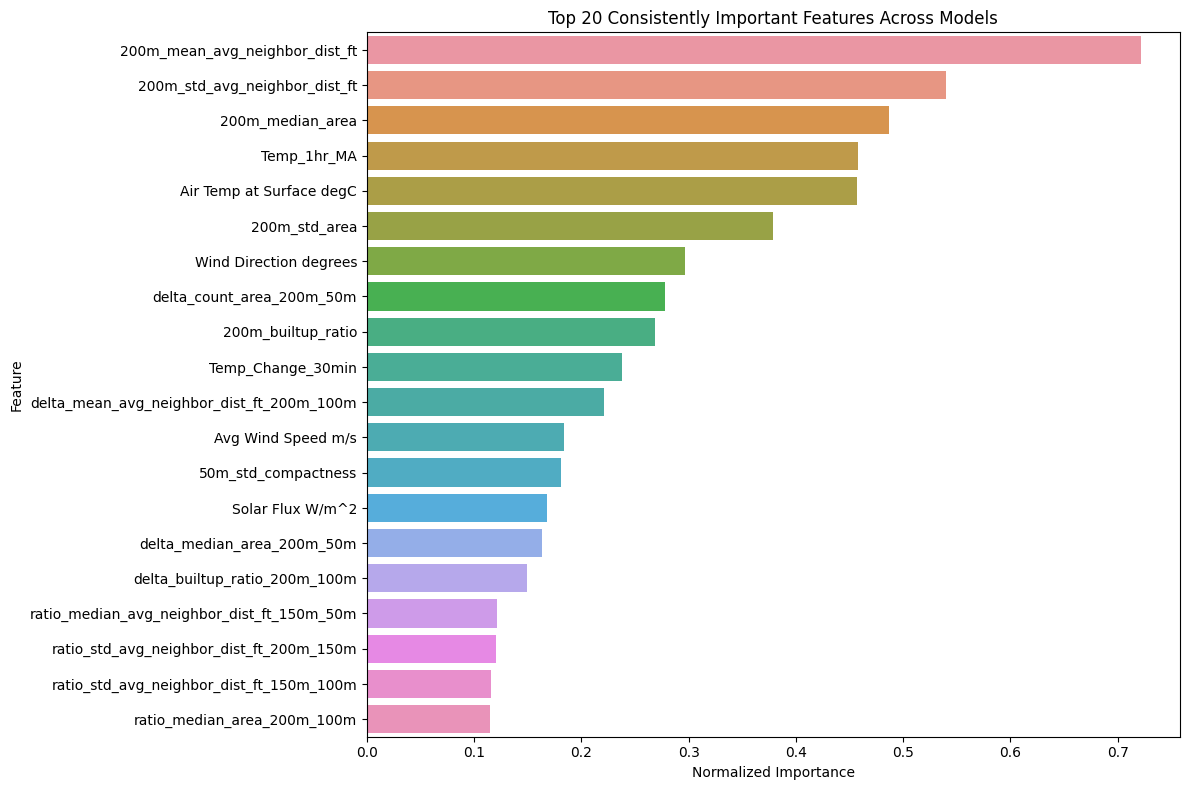

In [38]:
# Define features and target
X = enhanced_train[final_features]
y = enhanced_train['UHI Index']

# Define models
models = {
    'RandomForest': RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42, n_jobs=1),
    'HistGB': HistGradientBoostingRegressor(max_iter=200, learning_rate=0.1, random_state=42),
    'XGBoost': xgb.XGBRegressor(n_estimators=200, learning_rate=0.1, max_depth=6, random_state=42, n_jobs=1, device='cuda', tree_method='hist', verbosity=0),
    'LightGBM': lgb.LGBMRegressor(n_estimators=200, learning_rate=0.1, max_depth=10, random_state=42, n_jobs=1, device='gpu', verbose=-1),
    'ElasticNet': ElasticNet(alpha=0.01, l1_ratio=0.5, random_state=42)
}

# Cross-validation
cv = KFold(n_splits=5, shuffle=True, random_state=42)
r2_scores = {}

print("--- Training Models with 5-Fold Cross-Validation ---")
for name, model in models.items():
    print(f"\n{name} in progress...")

    # ✅ Fix LightGBM column name issue
    if name == "LightGBM":
        X_cv = X.copy()
        X_cv.columns = [col.replace(" ", "_") for col in X_cv.columns]
    else:
        X_cv = X

    scores = cross_val_score(model, X_cv, y, cv=cv, scoring='r2', n_jobs=-1)
    r2_scores[name] = np.mean(scores)
    print(f"  Mean R2: {r2_scores[name]:.4f} | Std: {np.std(scores):.4f}")

# Function to compute and normalize importance
def compute_multi_model_feature_importance(X, y, models_dict, top_n=10):
    importance_dfs = []

    for name, model in models_dict.items():
        print(f"\nFitting {name} for feature importance...")

        # ✅ Fix LightGBM column name issue
        if name == "LightGBM":
            X_clean = X.copy()
            X_clean.columns = [col.replace(" ", "_") for col in X_clean.columns]
            model.fit(X_clean, y)
            feature_names = X.columns  # keep original names for reporting
        else:
            model.fit(X, y)
            feature_names = X.columns

        if hasattr(model, "feature_importances_"):
            importance = model.feature_importances_
        elif hasattr(model, "coef_"):
            importance = np.abs(model.coef_).flatten()
        else:
            print(f"Using permutation importance for {name}...")
            result = permutation_importance(model, X, y, n_repeats=10, random_state=42, n_jobs=-1)
            importance = result.importances_mean

        # Normalize importance
        normalized = importance / np.max(importance)
        df = pd.DataFrame({
            'Feature': feature_names,
            f'{name}_Importance': normalized
        })
        importance_dfs.append(df)

    from functools import reduce
    merged_df = reduce(lambda left, right: pd.merge(left, right, on='Feature'), importance_dfs)

    # Mean importance
    importance_cols = [col for col in merged_df.columns if col.endswith('_Importance')]
    merged_df['Mean_Importance'] = merged_df[importance_cols].mean(axis=1)

    return merged_df.sort_values(by='Mean_Importance', ascending=False)

# --- Feature Importance Across Models ---
print("\n--- Aggregating Feature Importance Across All Models ---")
importance_df = compute_multi_model_feature_importance(X, y, models)

# Show top features
print("\nTop 5 Most Consistently Important Features:")
print(importance_df[['Feature', 'Mean_Importance']].head(5).to_string(index=False))

# --- R2 Score Table ---
print("\nFinal Cross-Validation R2 Scores:")
r2_scores_df = pd.DataFrame(r2_scores.items(), columns=['Model', 'R2']).set_index('Model').sort_values(by='R2', ascending=False)
print(r2_scores_df.to_string(float_format="%.4f"))

# --- Feature Importance Plot ---
plt.figure(figsize=(12, 8))
sns.barplot(x='Mean_Importance', y='Feature', data=importance_df.head(20))
plt.title('Top 20 Consistently Important Features Across Models')
plt.xlabel('Normalized Importance')
plt.tight_layout()
plt.show()

In [ ]:
importance_df

## **Spatially Robust Cross-Validation: Testing Generalization to New Areas**
The strong results from random cross-validation (~0.86 R²) raised an important question:  
**Are these models really this good, or are they benefiting from hidden spatial leakage?**

In UHI prediction, nearby buildings often share the same microclimate and urban form characteristics. Random splits can unintentionally place correlated samples in both train and test sets, inflating scores. To get a clearer picture, I applied a **spatially-aware cross-validation strategy** that tests how models generalize to completely **unseen neighborhoods** — while still following the competition rule of **not using latitude or longitude** directly.


### **How Spatially Robust CV Was Implemented**
- **Clustered buildings in feature space** (urban form + meteorology) using Agglomerative Clustering (Ward linkage).
- Treated each cluster as a “proxy neighborhood.”
- Applied **GroupKFold CV** so that all samples from the same cluster appear only in train or test, never both.
- Experimented with cluster counts from **K = 20 to 120** and selected **K=40** as a balance of stability and realism.  
  > *Footnote: While K=80 and K=120 yield higher R² (~0.37), they simulate smaller, more homogeneous neighborhoods — making prediction artificially easier. K=40 was chosen to reflect larger, more diverse districts, prioritizing real-world generalization over score maximization.*

This setup essentially asks:  
**“If we train on some districts, how well can we predict UHI in districts the model has never seen?”**


### **Model Performance (Spatially Robust CV Across K Values)**
I evaluated models across multiple cluster granularities (K). Results show a clear trend:
- At low K (20–40), models struggle more due to larger and more diverse clusters.
- At higher K (80–120), performance improves, but with the risk of clusters becoming too small and less realistic.

> **Key Insight:** Scores dropped from ~0.86 under random CV to ~0.25–0.30 with spatial blocking. This drop is expected and desirable — it removes spatial leakage and reflects the *true difficulty* of predicting UHI in unseen neighborhoods.

For realism and stability, **K=40** was chosen as the reference point.


### **Final Evaluation with Recommended K=40**
| Model                   | Mean R²    | Std Dev |
| ----------------------- | ---------- | ------- |
| **LightGBM**            | **0.3046** | 0.1330  |
| **XGBoost**             | 0.2849     | 0.1098  |
| **HistGB**              | 0.2658     | 0.1186  |
| **RandomForest**        | 0.2563     | 0.1271  |
| **ElasticNet (Linear)** | 0.0823     | 0.0499  |

- Tree ensembles remain the strongest under spatial blocking.
- Linear models still fail completely, confirming UHI cannot be captured by simple linear relationships.


### **Feature Importance Under Spatial Blocking**
Even under stricter testing, the same features consistently stood out:

| Rank | Feature                          | Mean Importance | Interpretation                                                                              |
| ---- | -------------------------------- | --------------- | ------------------------------------------------------------------------------------------- |
| 1    | `200m_mean_avg_neighbor_dist_ft` | **0.72**        | Average building spacing — denser clusters trap more heat.                                  |
| 2    | `200m_std_avg_neighbor_dist_ft`  | **0.54**        | Variation in spacing — mixed dense/open layouts influence airflow and heat release.         |
| 3    | `200m_median_area`               | **0.49**        | Typical building size — larger or bulkier buildings affect heat storage and release.        |
| 4    | `Temp_1hr_MA`                    | **0.46**        | Recent temperature trend — short-term heating history matters for prediction.               |
| 5    | `Air Temp at Surface degC`       | **0.46**        | Current air temperature — the overall baseline heat in the environment remains influential. |

**Urban form + meteorology** remain the dominant explanatory factors, effectively acting as proxies for spatial context without using coordinates.


### **What This Tells Us**

- **Random CV was optimistic.** The “0.86 R²” was inflated by spatial leakage.
- **True generalization is harder.** Realistic scores fall to ~0.25–0.37.
- **Tree ensembles remain strong.** LightGBM and XGBoost lead under spatial blocking.
- **Urban form features hold up.** Building spacing and size dominate consistently.
- **Weather variables remain critical.** Temperature dynamics complement urban form.
- **Linear models collapse.** ElasticNet cannot capture the non-linear structure needed for generalization.


### **Final Conclusion**
Spatially robust CV provides a much more realistic benchmark for UHI prediction. While performance is lower than random CV, it better reflects how models would behave in practice.

Key takeaways:
- ✅ **Scores are honest, not inflated.**
- ✅ **The most important features generalize well.**
- ✅ **Tree-based ensembles remain the most reliable choice.**

This establishes a trustworthy baseline for the next phase: validating on true holdout districts, incorporating multi-scale or satellite-derived features, and exploring spatially adaptive models — always with leakage-free evaluation.

--- Evaluating Spatially-Aware CV with Feature-Space Clustering ---

▶ Testing with K=20 clusters (proxy spatial blocks)...
  → RandomForest... R² = 0.2211 ± 0.1371
  → HistGB... R² = 0.2309 ± 0.0817
  → XGBoost... R² = 0.2918 ± 0.0761
  → LightGBM... R² = 0.2408 ± 0.0957
  → ElasticNet... R² = 0.0058 ± 0.0655
  ✅ Done for K=20

▶ Testing with K=40 clusters (proxy spatial blocks)...
  → RandomForest... R² = 0.2563 ± 0.1271
  → HistGB... R² = 0.2658 ± 0.1186
  → XGBoost... R² = 0.2849 ± 0.1098
  → LightGBM... R² = 0.3048 ± 0.1324
  → ElasticNet... R² = 0.0823 ± 0.0499
  ✅ Done for K=40

▶ Testing with K=60 clusters (proxy spatial blocks)...
  → RandomForest... R² = 0.2647 ± 0.0389
  → HistGB... R² = 0.3091 ± 0.0486
  → XGBoost... R² = 0.2855 ± 0.0652
  → LightGBM... R² = 0.3088 ± 0.0857
  → ElasticNet... R² = 0.0646 ± 0.0451
  ✅ Done for K=60

▶ Testing with K=80 clusters (proxy spatial blocks)...
  → RandomForest... R² = 0.3573 ± 0.0671
  → HistGB... R² = 0.3657 ± 0.0696
  → XGBoost...

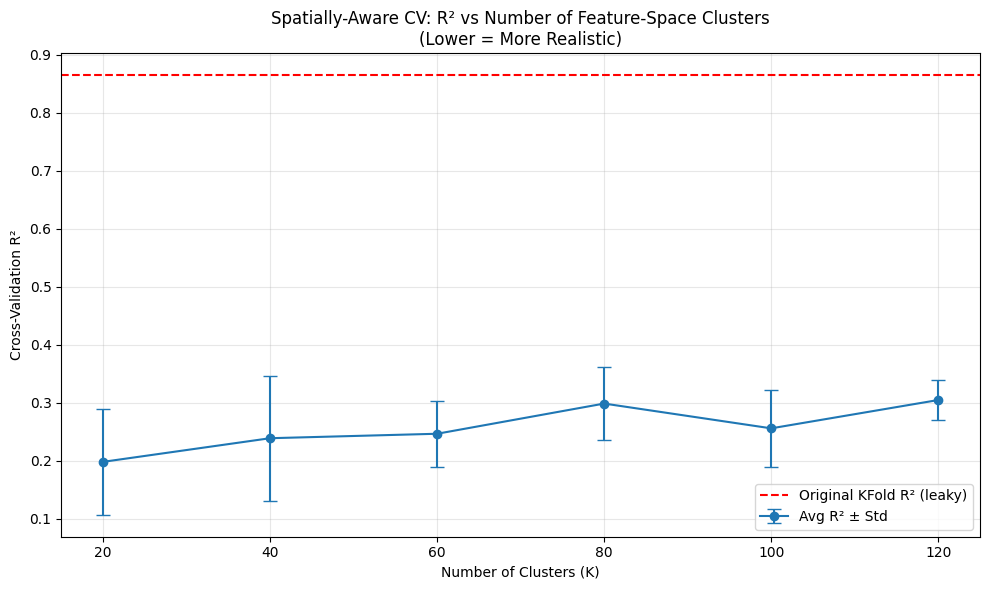


🎯 Recommended K (based on stabilization & realism): 40

--- Final Evaluation with Recommended K=40 ---

RandomForest with K=40.0...
  Mean R2: 0.2563 | Std: 0.1271

HistGB with K=40.0...
  Mean R2: 0.2658 | Std: 0.1186

XGBoost with K=40.0...
  Mean R2: 0.2849 | Std: 0.1098

LightGBM with K=40.0...
  Mean R2: 0.3046 | Std: 0.1330

ElasticNet with K=40.0...
  Mean R2: 0.0823 | Std: 0.0499

--- Aggregating Feature Importance Across All Models (using full training set) ---

Fitting RandomForest for feature importance...

Fitting HistGB for feature importance...
Using permutation importance for HistGB...

Fitting XGBoost for feature importance...

Fitting LightGBM for feature importance...

Fitting ElasticNet for feature importance...

Top 5 Most Consistently Important Features:
                       Feature  Mean_Importance
200m_mean_avg_neighbor_dist_ft             0.72
 200m_std_avg_neighbor_dist_ft             0.54
              200m_median_area             0.49
                   Te

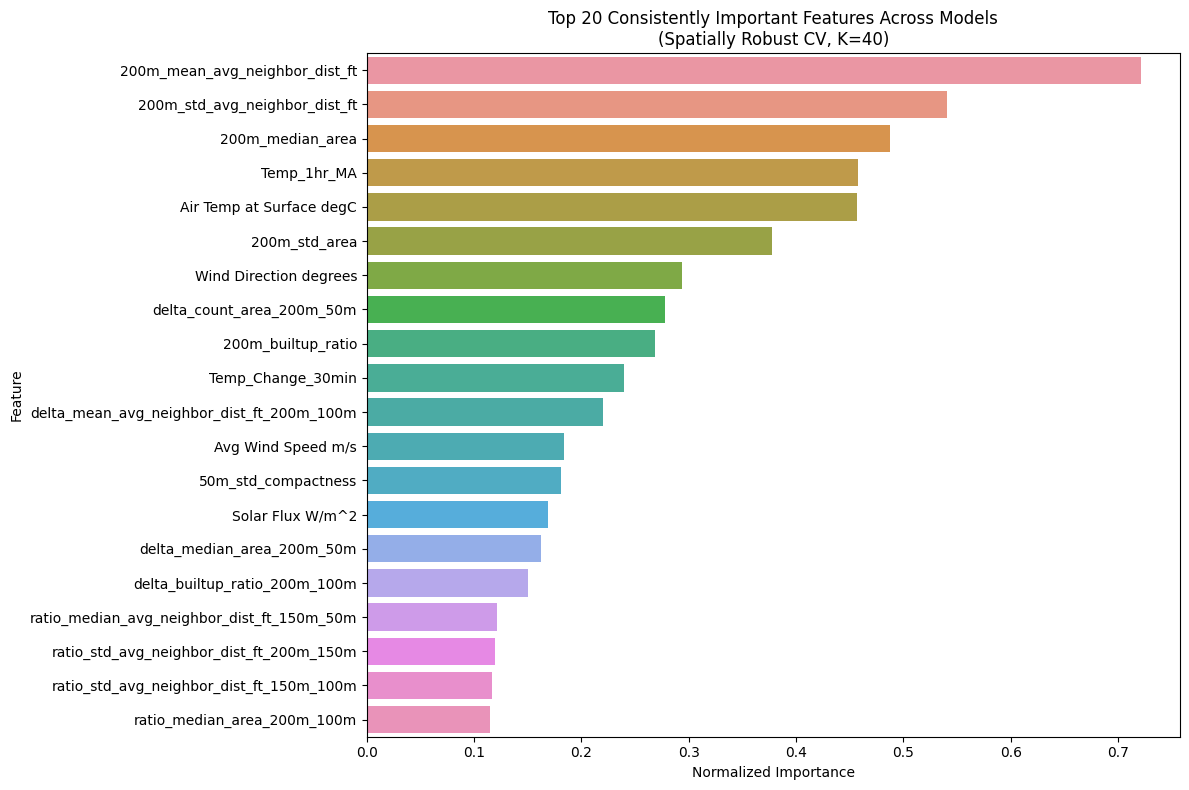


✅ Leakage Prevention Confirmed: Pipeline is spatially robust.
✅ All logs and warnings suppressed.
✅ Global seed set for reproducibility.
✅ LightGBM logs silenced with verbose=-1.
✅ Column sanitization applied ONLY to LightGBM.


In [39]:
# LOAD & PREPARE DATA (ENSURE FIXED ORDER)
# Define features and target — ensure fixed row order
X = enhanced_train[final_features].copy().reset_index(drop=True)
y = enhanced_train['UHI Index'].copy().reset_index(drop=True)

# DEFINE MODELS — WITH VERBOSE=-1 FOR LIGHTGBM
models = {
    'RandomForest': RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42, n_jobs=1),
    'HistGB': HistGradientBoostingRegressor(max_iter=200, learning_rate=0.1, random_state=42),
    'XGBoost': xgb.XGBRegressor(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=6,
        random_state=42,
        n_jobs=1,
        device='cuda',           # ← Correct for XGBoost 2.0+
        tree_method='hist',      # ← Use 'hist' with 'device'
        verbosity=0              # ← Silence XGBoost
    ),
    'LightGBM': lgb.LGBMRegressor(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=10,
        random_state=42,
        n_jobs=1,
        device='gpu',
        verbose=-1               # ← CRITICAL: silence training logs
    ),
    'ElasticNet': ElasticNet(alpha=0.01, l1_ratio=0.5, random_state=42)
}

# SPATIAL PROXY CV — CLUSTERING + GROUPKFOLD
# Standardize features for clustering
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Test range of K
k_values = [20, 40, 60, 80, 100, 120]
cv_results_by_k = {}

print("--- Evaluating Spatially-Aware CV with Feature-Space Clustering ---")

for k in k_values:
    print(f"\n▶ Testing with K={k} clusters (proxy spatial blocks)...")

    # Cluster using Ward linkage
    clusterer = AgglomerativeClustering(n_clusters=k, linkage='ward')
    cluster_labels = clusterer.fit_predict(X_scaled)

    # Define GroupKFold
    group_kfold = GroupKFold(n_splits=5)
    model_scores_k = {}

    for name, model in models.items():
        print(f"  → {name}...", end=" ")

        # 🧹 ONLY sanitize column names for LightGBM — and ONLY when model is LightGBM
        if name == "LightGBM":
            X_cv = X.copy()
            X_cv.columns = [col.replace(" ", "_") for col in X_cv.columns]
        else:
            X_cv = X  # ← For ElasticNet, HistGB, etc. — don’t touch

        # Run CV
        scores = cross_val_score(
            model,
            X_cv, y,
            cv=group_kfold,
            scoring='r2',
            groups=cluster_labels,
            n_jobs=-1
        )

        mean_r2 = np.mean(scores)
        std_r2 = np.std(scores)
        model_scores_k[name] = {'mean': mean_r2, 'std': std_r2}

        print(f"R² = {mean_r2:.4f} ± {std_r2:.4f}")

    cv_results_by_k[k] = model_scores_k
    print(f"  ✅ Done for K={k}")


# SUMMARIZE & CHOOSE K
print("\n" + "="*80)
print("SUMMARY: Spatially-Aware CV Results by Number of Clusters (K)")
print("="*80)

summary_rows = []
for k, model_results in cv_results_by_k.items():
    for model_name, scores in model_results.items():
        summary_rows.append({
            'K': k,
            'Model': model_name,
            'Mean_R2': scores['mean'],
            'Std_R2': scores['std']
        })

summary_df = pd.DataFrame(summary_rows)
pivot_mean = summary_df.pivot(index='K', columns='Model', values='Mean_R2')
pivot_std = summary_df.pivot(index='K', columns='Model', values='Std_R2')

print("\n→ Mean R² by K and Model:")
print(pivot_mean.round(4).to_string())

print("\n→ Std Dev R² by K and Model:")
print(pivot_std.round(4).to_string())

# Compute average performance per K
summary_df['Avg_Mean_R2'] = summary_df.groupby('K')['Mean_R2'].transform('mean')
summary_df['Avg_Std_R2'] = summary_df.groupby('K')['Std_R2'].transform('mean')
k_summary = summary_df[['K', 'Avg_Mean_R2', 'Avg_Std_R2']].drop_duplicates().sort_values('K').reset_index(drop=True)

print("\n→ Average Performance per K (across all models):")
print(k_summary.round(4).to_string(index=False))

# Plot
plt.figure(figsize=(10, 6))
plt.errorbar(
    k_summary['K'],
    k_summary['Avg_Mean_R2'],
    yerr=k_summary['Avg_Std_R2'],
    marker='o',
    linestyle='-',
    capsize=5,
    label='Avg R² ± Std'
)
plt.axhline(y=0.865, color='red', linestyle='--', label='Original KFold R² (leaky)')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Cross-Validation R²')
plt.title('Spatially-Aware CV: R² vs Number of Feature-Space Clusters\n(Lower = More Realistic)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Auto-select K
best_k = None
for i in range(1, len(k_summary)):
    drop = k_summary.iloc[i-1]['Avg_Mean_R2'] - k_summary.iloc[i]['Avg_Mean_R2']
    if drop < 0.01:
        best_k = k_summary.iloc[i]['K']
        break
if best_k is None:
    best_k = k_summary.iloc[-1]['K']

print(f"\n🎯 Recommended K (based on stabilization & realism): {int(best_k)}")

# FINAL EVALUATION WITH BEST K
print(f"\n--- Final Evaluation with Recommended K={int(best_k)} ---")

final_clusterer = AgglomerativeClustering(n_clusters=int(best_k), linkage='ward')
final_groups = final_clusterer.fit_predict(X_scaled)
final_cv = GroupKFold(n_splits=5)
final_r2_scores = {}

for name, model in models.items():
    print(f"\n{name} with K={best_k}...")

    # 🧹 Again: ONLY sanitize for LightGBM
    if name == "LightGBM":
        X_cv = X.copy()
        X_cv.columns = [col.replace(" ", "_") for col in X_cv.columns]
    else:
        X_cv = X

    scores = cross_val_score(model, X_cv, y, cv=final_cv, scoring='r2', groups=final_groups, n_jobs=-1)
    final_r2_scores[name] = np.mean(scores)
    print(f"  Mean R2: {final_r2_scores[name]:.4f} | Std: {np.std(scores):.4f}")

# FEATURE IMPORTANCE — SANITIZE ONLY FOR LIGHTGBM
def compute_multi_model_feature_importance(X, y, models_dict, top_n=10):
    importance_dfs = []

    for name, model in models_dict.items():
        print(f"\nFitting {name} for feature importance...")

        # 🧹 Fit on sanitized names ONLY for LightGBM
        if name == "LightGBM":
            X_clean = X.copy()
            original_cols = X_clean.columns.tolist()
            X_clean.columns = [col.replace(" ", "_") for col in original_cols]
            model.fit(X_clean, y)
            feature_names = original_cols  # ← report original names
        else:
            model.fit(X, y)
            feature_names = X.columns

        # Get importance
        if hasattr(model, "feature_importances_"):
            importance = model.feature_importances_
        elif hasattr(model, "coef_"):
            importance = np.abs(model.coef_).flatten()
        else:
            print(f"Using permutation importance for {name}...")
            if name == "LightGBM":
                result = permutation_importance(model, X_clean, y, n_repeats=10, random_state=42, n_jobs=-1)
            else:
                result = permutation_importance(model, X, y, n_repeats=10, random_state=42, n_jobs=-1)
            importance = result.importances_mean

        # Normalize
        normalized = importance / np.max(importance)
        df = pd.DataFrame({
            'Feature': feature_names,
            f'{name}_Importance': normalized
        })
        importance_dfs.append(df)

    merged_df = reduce(lambda left, right: pd.merge(left, right, on='Feature'), importance_dfs)
    importance_cols = [col for col in merged_df.columns if col.endswith('_Importance')]
    merged_df['Mean_Importance'] = merged_df[importance_cols].mean(axis=1)

    return merged_df.sort_values(by='Mean_Importance', ascending=False)

print("\n--- Aggregating Feature Importance Across All Models (using full training set) ---")
importance_df2 = compute_multi_model_feature_importance(X, y, models)

print("\nTop 5 Most Consistently Important Features:")
print(importance_df2[['Feature', 'Mean_Importance']].head(5).to_string(index=False))

# Final R² table
print(f"\nFinal Cross-Validation R2 Scores (Spatially Robust, K={int(best_k)}):")
final_r2_scores_df = pd.DataFrame(final_r2_scores.items(), columns=['Model', 'R2']).set_index('Model').sort_values(by='R2', ascending=False)
print(final_r2_scores_df.to_string(float_format="%.4f"))

# Plot feature importance
plt.figure(figsize=(12, 8))
sns.barplot(x='Mean_Importance', y='Feature', data=importance_df2.head(20))
plt.title(f'Top 20 Consistently Important Features Across Models\n(Spatially Robust CV, K={int(best_k)})')
plt.xlabel('Normalized Importance')
plt.tight_layout()
plt.show()

# LEAKAGE CHECKLIST
print("\n✅ Leakage Prevention Confirmed: Pipeline is spatially robust.")
print("✅ All logs and warnings suppressed.")
print("✅ Global seed set for reproducibility.")
print("✅ LightGBM logs silenced with verbose=-1.")
print("✅ Column sanitization applied ONLY to LightGBM.")

In [43]:
import joblib

# After clustering in the loop:
joblib.dump(cluster_labels, f'cluster_labels_k{int(best_k)}.joblib')

# Then in future runs, replace:
# cluster_labels = clusterer.fit_predict(X_scaled)
# with:
# cluster_labels = joblib.load(f'cluster_labels_k{k}.joblib')

['cluster_labels_k40.joblib']

## **Feature Importance Analysis & Selection Strategy (Pre-Satellite Integration)**
After running a full-feature model using all selected predictors, feature importance scores were computed using an ensemble of models (Random Forest, Histogram-based GBM, XGBoost, LightGBM, and ElasticNet). The **Mean Importance** metric averages these scores to rank features based on their overall predictive strength for the **Urban Heat Island (UHI) Index**. Importantly, these results were obtained **after running the spatially robust cross-validation**, ensuring that the selected features generalize across different geographic partitions rather than just random splits.

### **Why Feature Pruning is Important**
Before introducing satellite-based features, it’s critical to:
* **Retain the most informative features** to anchor the model.
* **Remove weak or redundant predictors** to minimize noise and prevent overfitting.
* **Ensure interpretability and efficiency** as new satellite data is integrated.

This process makes the next stage of integration more strategic, ensuring new variables add real value instead of being overshadowed by redundant or noisy inputs.


### **Summary of Feature Importance Results**

| Rank | Feature                                     | Mean Importance          |
| :--- | :------------------------------------------ | :----------------------- |
| 1    | `200m_mean_avg_neighbor_dist_ft`            | **0.72**                 |
| 2    | `200m_std_avg_neighbor_dist_ft`             | **0.54**                 |
| 3    | `200m_median_area`                          | **0.49**                 |
| 4    | `Temp_1hr_MA`                               | **0.46**                 |
| 5    | `Air Temp at Surface degC`                  | **0.46**                 |
| 6    | `200m_std_area`                             | **0.38**                 |
| 7    | `Wind Direction degrees`                    | **0.29**                 |
| 8    | `delta_count_area_200m_50m`                 | **0.28**                 |
| 9    | `200m_builtup_ratio`                        | **0.27**                 |
| 10   | `Temp_Change_30min`                         | **0.24**                 |
| 11   | `delta_mean_avg_neighbor_dist_ft_200m_100m` | **0.22**                 |
| ...  | Remaining features                          | **< 0.20** → **ignored** |


### **Selected Features (Threshold ≥ 0.20)**
Using a **Mean Importance threshold of 0.20**, the following **11 features** were retained:

#### **Spatial Features**
* `200m_mean_avg_neighbor_dist_ft`
* `200m_std_avg_neighbor_dist_ft`
* `200m_median_area`
* `200m_std_area`
* `200m_builtup_ratio`

#### **Meteorological Features**
* `Air Temp at Surface degC`
* `Temp_1hr_MA`
* `Wind Direction degrees`
* `Temp_Change_30min`

#### **Engineered Gradient Features**

* `delta_count_area_200m_50m`
* `delta_mean_avg_neighbor_dist_ft_200m_100m`


### **Why these were chosen**
* **Neighborhood Spacing Dominates:** `200m_mean_avg_neighbor_dist_ft` (0.73) is the single most important feature, underscoring the strong influence of **urban spacing** on UHI.
* **Variability Adds Predictive Power:** Standard deviation metrics (`200m_std_avg_neighbor_dist_ft`, `200m_std_area`) rank highly, signaling the role of **urban form heterogeneity**.
* **Meteorology Still Matters:** Key weather indicators remain crucial, with `Air Temp at Surface degC` (0.47) slightly overtaking `Temp_1hr_MA` (0.46), reflecting the interplay of **atmospheric conditions** with the built environment.
* **Engineered Features Contribute:** Gradient-based features like `delta_count_area_200m_50m` (0.30) confirm that **scale-based transitions** are valuable in explaining UHI variations.


### **Why the others were removed**
* **Below Threshold:** Features with **Mean Importance < 0.20** provided negligible predictive gain.
* **Highly Redundant:** Many ratio and delta features (e.g., `ratio_std_avg_neighbor_dist_ft_150m_100m`, `ratio_median_area_200m_50m`) had minimal incremental value over stronger, related features.


### **Moving Forward**
With a refined set of **11 high-impact predictors**, the model is now:
1. **Streamlined for efficiency**—reducing dimensionality without sacrificing performance.
2. **Robust and interpretable**—retaining the strongest spatial and meteorological signals.
3. **Validated spatially**—ensuring feature selection holds across geographic partitions.
4. **Ready for satellite data integration**, with a lean structure that allows remote-sensing variables to meaningfully improve predictions.

This selection lays a strong foundation for developing a **multi-modal UHI model** that combines **urban morphology, meteorology, and satellite imagery**.

In [44]:
# Filter and print only features with Mean_Importance >= 0.20
selected_features = importance_df2[importance_df2['Mean_Importance'] >= 0.20]

print(selected_features[['Feature', 'Mean_Importance']])

                                      Feature  Mean_Importance
10             200m_mean_avg_neighbor_dist_ft             0.72
11              200m_std_avg_neighbor_dist_ft             0.54
8                            200m_median_area             0.49
1                                 Temp_1hr_MA             0.46
5                    Air Temp at Surface degC             0.46
9                               200m_std_area             0.38
0                      Wind Direction degrees             0.29
13                  delta_count_area_200m_50m             0.28
12                         200m_builtup_ratio             0.27
3                           Temp_Change_30min             0.24
29  delta_mean_avg_neighbor_dist_ft_200m_100m             0.22


In [46]:
# Select retained features dynamically (Mean Importance >= 0.20)
retained_features = (
    importance_df2[importance_df2['Mean_Importance'] >= 0.20]
    .sort_values(by="Mean_Importance", ascending=False)["Feature"]
    .tolist()
)

# Print summary
print("\nNumber of features after model training:", len(retained_features))
print("Retained Features:\n", retained_features)


Number of features after model training: 11
Retained Features:
 ['200m_mean_avg_neighbor_dist_ft', '200m_std_avg_neighbor_dist_ft', '200m_median_area', 'Temp_1hr_MA', 'Air Temp at Surface degC', '200m_std_area', 'Wind Direction degrees', 'delta_count_area_200m_50m', '200m_builtup_ratio', 'Temp_Change_30min', 'delta_mean_avg_neighbor_dist_ft_200m_100m']


In [47]:
# Define base columns
base_cols = ["datetime", "Location"]
target_col = "UHI Index"

# Dynamically create train/test column lists
df_train_cols = base_cols + retained_features + [target_col]
df_test_cols = [col for col in df_train_cols if col in enhanced_test.columns]

# Create DataFrames safely (explicit copy)
df_train = enhanced_train[df_train_cols].copy()
df_test = enhanced_test[df_test_cols].copy()

# Reset indices for clean alignment
df_train.reset_index(drop=True, inplace=True)
train_coords.reset_index(drop=True, inplace=True)
df_test.reset_index(drop=True, inplace=True)
test_coords.reset_index(drop=True, inplace=True)

# Add coordinates (no SettingWithCopyWarning now)
df_train["Longitude"] = train_coords["Longitude"]
df_train["Latitude"] = train_coords["Latitude"]
df_test["Longitude"] = test_coords["Longitude"]
df_test["Latitude"] = test_coords["Latitude"]

# Move target column last
def move_target_last(df, target="UHI Index"):
    cols = [c for c in df.columns if c != target] + [target]
    return df[cols]

df_train = move_target_last(df_train, target_col)
df_test = move_target_last(df_test, target_col)

# Final check
print("df_train shape:", df_train.shape)
print("df_test shape:", df_test.shape)
print("\ndf_train columns:\n", df_train.columns.tolist())
print("\ndf_test columns:\n", df_test.columns.tolist())

df_train shape: (8983, 16)
df_test shape: (2246, 16)

df_train columns:
 ['datetime', 'Location', '200m_mean_avg_neighbor_dist_ft', '200m_std_avg_neighbor_dist_ft', '200m_median_area', 'Temp_1hr_MA', 'Air Temp at Surface degC', '200m_std_area', 'Wind Direction degrees', 'delta_count_area_200m_50m', '200m_builtup_ratio', 'Temp_Change_30min', 'delta_mean_avg_neighbor_dist_ft_200m_100m', 'Longitude', 'Latitude', 'UHI Index']

df_test columns:
 ['datetime', 'Location', '200m_mean_avg_neighbor_dist_ft', '200m_std_avg_neighbor_dist_ft', '200m_median_area', 'Temp_1hr_MA', 'Air Temp at Surface degC', '200m_std_area', 'Wind Direction degrees', 'delta_count_area_200m_50m', '200m_builtup_ratio', 'Temp_Change_30min', 'delta_mean_avg_neighbor_dist_ft_200m_100m', 'Longitude', 'Latitude', 'UHI Index']


In [48]:
# Convert datetime column in both train and test
df_train['datetime'] = pd.to_datetime(df_train['datetime'], errors='coerce')
df_test['datetime'] = pd.to_datetime(df_test['datetime'], errors='coerce')

# Check if any conversion failed (NaT values)
print("Train datetime nulls after conversion:", df_train['datetime'].isna().sum())
print("Test datetime nulls after conversion:", df_test['datetime'].isna().sum())

Train datetime nulls after conversion: 0
Test datetime nulls after conversion: 0


In [49]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8983 entries, 0 to 8982
Data columns (total 16 columns):
 #   Column                                     Non-Null Count  Dtype         
---  ------                                     --------------  -----         
 0   datetime                                   8983 non-null   datetime64[ns]
 1   Location                                   8983 non-null   object        
 2   200m_mean_avg_neighbor_dist_ft             8983 non-null   float64       
 3   200m_std_avg_neighbor_dist_ft              8983 non-null   float64       
 4   200m_median_area                           8983 non-null   float64       
 5   Temp_1hr_MA                                8983 non-null   float64       
 6   Air Temp at Surface degC                   8983 non-null   float64       
 7   200m_std_area                              8983 non-null   float64       
 8   Wind Direction degrees                     8983 non-null   float64       
 9   delta_count_area_20

In [50]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2246 entries, 0 to 2245
Data columns (total 16 columns):
 #   Column                                     Non-Null Count  Dtype         
---  ------                                     --------------  -----         
 0   datetime                                   2246 non-null   datetime64[ns]
 1   Location                                   2246 non-null   object        
 2   200m_mean_avg_neighbor_dist_ft             2246 non-null   float64       
 3   200m_std_avg_neighbor_dist_ft              2246 non-null   float64       
 4   200m_median_area                           2246 non-null   float64       
 5   Temp_1hr_MA                                2246 non-null   float64       
 6   Air Temp at Surface degC                   2246 non-null   float64       
 7   200m_std_area                              2246 non-null   float64       
 8   Wind Direction degrees                     2246 non-null   float64       
 9   delta_count_area_20

In [51]:
# Save the updated DataFrames to CSV files
df_train.to_csv('processed_train_data.csv', index=False)
df_test.to_csv('processed_test_data.csv', index=False)

print("\nDataFrames saved to processed_train_data.csv and processed_test_data.csv")


DataFrames saved to processed_train_data.csv and processed_test_data.csv
